In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    (path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
     if (path / "scripts").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find the repository scripts directory.")

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

FIG_DIR_ROOT = PROJECT_ROOT / "figures" / "arctic_amplification/50n"

In [82]:
import os
from pathlib import Path
import json
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional

In [83]:
class ArcticAAPlotter:
    """
    Plot AA time series and show summary statistics produced by ArcticAAProcessor.

    Expected files (from ArcticAAProcessor.run_and_save):
      AA_{EXP}_{ANCHOR}_ts_{GROUP}_{VAR}_{SEASON}_{PTARGT0}-{PTARGT1}_{WIN}yr_{ANCHOR}.nc
      AA_{EXP}_{ANCHOR}_ts_{GROUP}_{VAR}_{SEASON}_{PTARGT0}-{PTARGT1}_{WIN}yr_{ANCHOR}.json

    Examples of prefixes (everything before SEASON):
      "AA_ERA5_center_ts_ERA5_TS"
      "AA_E3SMv3-LE_center_ts_v3.LR.historical_TS"

    Features:
      - understands anchors: 'center' | 'start' | 'end'
      - prefers fixed processor axis 'time_year' / 'time_label_year'
      - DOES NOT trim to obs–model overlap (model can extend beyond ERA5)
      - loads and prints stats from the paired JSON
      - optional member spaghetti overlay for model
      - stats box layout selectable: "split" (two boxes) or "single"
    """

    def __init__(
        self,
        *,
        fig_dir,
        out_dir,
        ptargt=(1979, 2018),
        trend_window=30,
        trend_anchor="center",
        var="TS",
        pattern=None,
        verbose=True,
        show_ref_line=True,
        ref_value=2.0,
        color_obs="red",
        color_mean="k",
        color_members="gray",
        lw_mean=2.0,
        lw_obs=2.0,
        lw_member=0.8,
        alpha_member=0.3,
        dpi=300,
        fontz=12,                        # ← new
        show_stats=False,
        stats_layout="split",
        stats_fontsize=None,             # ← now optional, scales with fontz
        stats_keys=("AA_bar_mean","AA_bar_std","frac_time_AA_gt_gate_mean","n_ens","n_time","trend_anchor"),
        stats_pos_obs=(0.98, 0.95),
        stats_pos_mod=(0.98, 0.68),
    ):

        self.fig_dir = fig_dir
        self.out_dir = out_dir
        self.ptargt = tuple(ptargt)
        self.trend_window = int(trend_window)
        self.trend_anchor = None
        self.var = var
        self.pattern = pattern
        self.verbose = verbose

        self.show_ref_line = bool(show_ref_line)
        self.ref_value = float(ref_value)
        self.color_obs = color_obs
        self.color_mean = color_mean
        self.color_members = color_members
        self.lw_mean = float(lw_mean)
        self.lw_obs = float(lw_obs)
        self.lw_member = float(lw_member)
        self.alpha_member = float(alpha_member)
        self.dpi = int(dpi)

        # stats
        self.show_stats = bool(show_stats)
        self.stats_layout = str(stats_layout).lower()
        self.stats_keys = tuple(stats_keys)
        self.stats_pos_obs = tuple(stats_pos_obs)
        self.stats_pos_mod = tuple(stats_pos_mod)

        self.fontz = int(fontz)
        self.stats_fontsize = int(stats_fontsize or self.fontz * 0.8)
        
        plt.rcParams.update({
            "font.size": self.fontz,
            "axes.titlesize": self.fontz * 1.1,
            "axes.labelsize": self.fontz,
            "xtick.labelsize": self.fontz * 0.9,
            "ytick.labelsize": self.fontz * 0.9,
            "legend.fontsize": self.fontz * 0.9,
        })
        
        Path(fig_dir).mkdir(parents=True, exist_ok=True)

    # ---------- filename helpers ----------
    def _modern_name(self, prefix, season, ptargt=None, anchor=None, with_anchor=True):
        p0, p1 = (ptargt or self.ptargt)
        anc = (anchor or self.trend_anchor)
        if with_anchor:
            return f"{prefix}_{season}_{p0}-{p1}_{self.trend_window}yr_{anc}.nc"
        else:
            return f"{prefix}_{season}_{p0}-{p1}_{self.trend_window}yr.nc"

    def _candidate_paths(self, prefix, season):
        p0, p1 = self.ptargt
        exact_modern = os.path.join(self.out_dir, self._modern_name(prefix, season, (p0, p1), self.trend_anchor, True))
        exact_noanch = os.path.join(self.out_dir, self._modern_name(prefix, season, (p0, p1), self.trend_anchor, False))

        fallback_spans = [(1979, 2018), (1979, 2050)]
        alts = [exact_modern, exact_noanch]
        for a, b in fallback_spans:
            alts.append(os.path.join(self.out_dir, self._modern_name(prefix, season, (a, b), self.trend_anchor, True)))
            alts.append(os.path.join(self.out_dir, self._modern_name(prefix, season, (a, b), self.trend_anchor, False)))

        if self.pattern:
            for kind in ("members", "mean"):
                alts.append(os.path.join(self.out_dir, self.pattern.format(
                    prefix=prefix, season=season, start=p0, end=p1, kind=kind
                )))

        glob_pat = os.path.join(self.out_dir, f"{prefix}_{season}_*_{self.trend_window}yr*.nc")
        return alts + sorted(glob.glob(glob_pat))

    def _open_first_existing(self, prefix, season):
        tried = []
        for p in self._candidate_paths(prefix, season):
            if os.path.exists(p):
                if self.verbose:
                    print(f"[load] {p}")
                return xr.open_dataset(p), p
            tried.append(p)
        raise FileNotFoundError(
            f"No AA file found for prefix={prefix!r}, season={season!r} in {self.out_dir}\n"
            f"Tried:\n  - " + "\n  - ".join(tried[:10]) + ("\n  ..." if len(tried) > 10 else "")
        )

    # ---------- data helpers ----------
    @staticmethod
    def _extract_year_axis(ds):
        """
        Prefer fixed processor axis. Order:
          1) time_year (coord)
          2) time_label_year (var)
          3) time_center_year (var)
          4) fallback: convert 'time' coord to calendar years
        """
        if "time_year" in ds.coords:
            return ds["time_year"].values.astype(float)
        if "time_label_year" in ds:
            return np.asarray(ds["time_label_year"].values, dtype=float)
        if "time_center_year" in ds:
            return np.asarray(ds["time_center_year"].values, dtype=float)
        try:
            return ds["time"].dt.year.values.astype(float)
        except Exception:
            return np.array([getattr(tt, "year", np.nan) for tt in ds["time"].values], dtype=float)

    def _load_bundle(self, prefix, season):
        ds, used = self._open_first_existing(prefix, season)
        t = self._extract_year_axis(ds)

        if "aa_mean" in ds:
            aa_mean = ds["aa_mean"].values
        elif "aa" in ds and "ens" in ds.dims:
            aa_mean = ds["aa"].mean("ens").values
        else:
            raise KeyError(f"'aa_mean' not present and no 'aa' members in {used}")
        aa_mem = ds["aa"].values if ("aa" in ds and "ens" in ds.dims) else None
        return t, aa_mean, aa_mem, used

    @staticmethod
    def _json_for_nc(nc_path):
        return nc_path[:-3] + ".json" if nc_path.endswith(".nc") else None

    def _load_stats(self, nc_path):
        jpath = self._json_for_nc(nc_path)
        if jpath and os.path.exists(jpath):
            with open(jpath, "r") as f:
                return json.load(f)
        if self.verbose:
            print(f"[warn] stats JSON missing for {nc_path}")
        return None

    # ---------- alignment for plotting WITHOUT trimming ----------
    @staticmethod
    def _union_axis_and_align(t1, y1, t2, y2):
        """
        Build a sorted union axis from t1 and t2 (float years).
        Return (t_union, y1_aligned, y2_aligned) with NaNs where missing.
        """
        t1 = np.asarray(t1, float)
        t2 = np.asarray(t2, float)
        t_union = np.unique(np.concatenate([t1, t2]))
        def _map(t_src, y_src):
            out = np.full(t_union.shape, np.nan, dtype=float)
            idx = np.nonzero(np.isin(t_union, t_src))[0]
            out[idx] = y_src
            return out
        return t_union, _map(t1, y1), _map(t2, y2)

    # ---------- stats boxes ----------
    def _format_stats_lines(self, s, label):
        mapping = {
            "AA_bar_mean": "AA_mean",
            "AA_bar_std": "σ(AA_mean)",
            "frac_time_AA_gt_gate_mean": "P(AA>gate)",
            "n_ens": "n_ens",
            "n_time": "n_time",
            "trend_anchor": "anchor",
        }
        if s is None:
            return [f"{label}:", "  (no stats)"]
        lines = [f"{label}:"]
        a = s.get("AA_bar_mean", None)
        b = s.get("AA_bar_std", None)
        if isinstance(a, (float, int)) and isinstance(b, (float, int)):
            lines.append(f"  {mapping['AA_bar_mean']} = {a:.2f} ± {b:.2f}")
        elif isinstance(a, (float, int)):
            lines.append(f"  {mapping['AA_bar_mean']} = {a:.2f}")
        elif isinstance(b, (float, int)):
            lines.append(f"  {mapping['AA_bar_std']} = {b:.2f}")
        order = ["frac_time_AA_gt_gate_mean", "n_ens", "n_time", "trend_anchor"]
        for k in order:
            if k in s:
                v = s[k]
                pretty = mapping.get(k, k)
                if isinstance(v, (float, int)):
                    lines.append(f"  {pretty} = {v:.2f}")
                else:
                    lines.append(f"  {pretty} = {v}")
        return lines

    def _draw_stats(self, ax, stats_obs, stats_mod):
        if not self.show_stats:
            return

        box_kw = dict(boxstyle="round,pad=0.4", fc="white", ec="0.5", alpha=0.92)
        kw = dict(fontsize=self.stats_fontsize, family="monospace")

        # ----------- helper: format one box -----------
        def fmt_lines(s, label):
            mapping = {
                "AA_bar_mean": "AA_mean",
                "AA_bar_std": "σ(AA_mean)",
                "frac_time_AA_gt_gate_mean": "P(AA>gate)",
                "n_ens": "n_ens",
                "n_time": "n_time",
                "trend_anchor": "anchor",
            }
            if s is None:
                return [f"{label}:", "  (no stats)"]
            lines = [f"{label}:"]
            a = s.get("AA_bar_mean", None)
            b = s.get("AA_bar_std", None)
            if isinstance(a, (float, int)) and isinstance(b, (float, int)):
                lines.append(f"  {mapping['AA_bar_mean']} = {a:.2f} ± {b:.2f}")
            elif isinstance(a, (float, int)):
                lines.append(f"  {mapping['AA_bar_mean']} = {a:.2f}")
            elif isinstance(b, (float, int)):
                lines.append(f"  {mapping['AA_bar_std']} = {b:.2f}")
            for k in ["frac_time_AA_gt_gate_mean", "n_ens", "n_time", "trend_anchor"]:
                if k in s:
                    v = s[k]
                    pretty = mapping.get(k, k)
                    lines.append(f"  {pretty} = {v:.2f}" if isinstance(v, (float,int)) else f"  {pretty} = {v}")
            return lines

        # ----------- layout modes -----------
        if self.stats_layout == "split":
            # stacked boxes (current default)
            txt_obs = "\n".join(fmt_lines(stats_obs, "ERA5"))
            txt_mod = "\n".join(fmt_lines(stats_mod, "Model"))
            ax.text(*self.stats_pos_obs, txt_obs, transform=ax.transAxes,
                    ha="right", va="top", bbox=box_kw, **kw)
            ax.text(*self.stats_pos_mod, txt_mod, transform=ax.transAxes,
                    ha="right", va="top", bbox=box_kw, **kw)

        elif self.stats_layout == "side":   # <---- NEW horizontal layout ----
            # Put two boxes side by side (ERA5 left, Model right)
            txt_obs = "\n".join(fmt_lines(stats_obs, "ERA5"))
            txt_mod = "\n".join(fmt_lines(stats_mod, "Model"))

            # default positions for side layout (top-right corner)
            x_right, y_top = 0.98, 0.95
            dx = 0.36  # horizontal spacing in axes fraction
            ax.text(x_right - dx, y_top, txt_obs, transform=ax.transAxes,
                    ha="right", va="top", bbox=box_kw, **kw)
            ax.text(x_right, y_top, txt_mod, transform=ax.transAxes,
                    ha="right", va="top", bbox=box_kw, **kw)

        else:
            # single combined box
            left = fmt_lines(stats_obs, "ERA5")
            right = fmt_lines(stats_mod, "Model")
            txt = "\n".join(left + right)
            ax.text(0.98, 0.02, txt, transform=ax.transAxes,
                    ha="right", va="bottom", bbox=box_kw, **kw)

    # ---------- plotting ----------
    def plot_one(
        self,
        *,
        prefix_obs,
        prefix_mod,
        season,
        title=None,
        xlim=(1970, 2040),
        ylim=(-1, 5),
        labels=["OBS","Model"],
        legend_loc="best",
        out_name=None,
        figsize=(5.6, 4.2),
    ):
        # Load (each series is already on the processor's fixed axis with NaNs)
        t_obs, y_obs_mean, _obs_mem, path_obs = self._load_bundle(prefix_obs, season)
        t_mod, y_mod_mean, y_mod_mem, path_mod = self._load_bundle(prefix_mod, season)

        # Build union axis; DO NOT trim to overlap
        t, y_obs, y_mod = self._union_axis_and_align(t_obs, y_obs_mean, t_mod, y_mod_mean)

        fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=self.dpi)

        # Members (gray) on the union axis
        if y_mod_mem is not None:
            out_mem = np.full((y_mod_mem.shape[0], t.size), np.nan, dtype=float)
            mask_mod_on_union = np.isin(t, t_mod)
            mask_union_on_mod = np.isin(t_mod, t)
            idx_union = np.nonzero(mask_mod_on_union)[0]
            out_mem[:, idx_union] = y_mod_mem[:, mask_union_on_mod]
            for i in range(out_mem.shape[0]):
                ax.plot(t, out_mem[i, :], lw=self.lw_member, alpha=self.alpha_member, color=self.color_members)

        # Model mean (black) and obs (red)
        ax.plot(t, y_obs, lw=self.lw_obs,  color=self.color_obs,  label=labels[0])
        ax.plot(t, y_mod, lw=self.lw_mean, color=self.color_mean, label=labels[1])

        # Shade PTARGT and optional AA=2 line
        #ax.axvspan(self.ptargt[0], self.ptargt[1], color="gray", alpha=0.15)
        if self.show_ref_line:
            ax.axhline(self.ref_value, lw=1.0, ls="--", color="k", alpha=0.5)

        # Style
        ax.set_xlim(*xlim); ax.set_ylim(*ylim)
        ax.set_xlabel("Year")
        ax.set_ylabel("Arctic amplification")
        ttl = title or f"Arctic Amplification ({season}, {self.trend_anchor}, {self.trend_window}-yr)"
        ax.set_title(ttl)
        ax.grid(True, alpha=0.3)
        ax.legend(frameon=True, loc=legend_loc)

        # Stats box(es)
        self._draw_stats(ax, self._load_stats(path_obs), self._load_stats(path_mod))

        fig.tight_layout()
        if out_name:
            out_path = os.path.join(self.fig_dir, out_name)
            fig.savefig(out_path, dpi=self.dpi, bbox_inches="tight")
            if self.verbose:
                print(f"[OK] saved {out_path}")
        return fig, ax

    def plot_all_seasons(
        self,
        *,
        prefix_obs,
        prefix_mod,
        seasons=("ANN", "DJF", "MAM", "JJA", "SON"),
        xlim=(1970, 2040),
        ylim=(-1, 5),
        filename_prefix="AA_compare",
        ext="pdf",
    ):
        for seas in (s.upper() for s in seasons):
            title = f"Arctic Amplification — {seas}"
            out_name = f"{filename_prefix}_{seas}_{self.trend_anchor}.{ext}"
            self.plot_one(
                prefix_obs=prefix_obs,
                prefix_mod=prefix_mod,
                season=seas,
                title=title,
                xlim=xlim,
                ylim=ylim,
                out_name=out_name,
            )

    def plot_seasons_grid(
        self,
        *,
        prefix_obs,
        prefix_mod,
        seasons=("ANN", "DJF", "MAM", "JJA", "SON"),
        ncols=5,
        xlim=(1970, 2040),
        ylim=(-1, 5),
        out_name="AA_compare_all_seasons.pdf",
        figsize_per_panel=(4.2, 3.6),
    ):
        seas = [s.upper() for s in seasons]
        n = len(seas)
        ncols = min(ncols, n)
        nrows = (n + ncols - 1) // ncols
        fig, axes = plt.subplots(
            nrows, ncols,
            figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
            dpi=self.dpi,
            squeeze=False,
            sharey=True,
        )

        for idx, seasn in enumerate(seas):
            r, c = divmod(idx, ncols)
            ax = axes[r, c]

            t_obs, y_obs_mean, _obs_mem, path_obs = self._load_bundle(prefix_obs, seasn)
            t_mod, y_mod_mean, y_mod_mem, path_mod = self._load_bundle(prefix_mod, seasn)
            t, y_obs, y_mod = self._union_axis_and_align(t_obs, y_obs_mean, t_mod, y_mod_mean)

            if y_mod_mem is not None:
                out_mem = np.full((y_mod_mem.shape[0], t.size), np.nan, dtype=float)
                mask_mod_on_union = np.isin(t, t_mod)
                mask_union_on_mod = np.isin(t_mod, t)
                idx_union = np.nonzero(mask_mod_on_union)[0]
                out_mem[:, idx_union] = y_mod_mem[:, mask_union_on_mod]
                for i in range(out_mem.shape[0]):
                    ax.plot(t, out_mem[i, :], lw=self.lw_member, alpha=self.alpha_member, color=self.color_members)

            ax.plot(t, y_mod, lw=self.lw_mean, color=self.color_mean, label="Model mean" if idx == 0 else None)
            ax.plot(t, y_obs, lw=self.lw_obs,  color=self.color_obs,  label="ERA5" if idx == 0 else None)

            ax.axvspan(self.ptargt[0], self.ptargt[1], color="gray", alpha=0.15)
            if self.show_ref_line:
                ax.axhline(self.ref_value, lw=1.0, ls="--", color="k", alpha=0.5)

            ax.set_xlim(*xlim); ax.set_ylim(*ylim)
            ax.set_title(f"{seasn} ({self.trend_anchor})")
            if c == 0:
                ax.set_ylabel("Arctic amplification")
            ax.grid(True, alpha=0.3)

        # shared legend
        handles, labels = axes[0, 0].get_legend_handles_labels()
        if handles:
            fig.legend(handles, labels, loc="upper left", frameon=False)

        fig.tight_layout()
        out_path = os.path.join(self.fig_dir, out_name.replace(".pdf", f"_{self.trend_anchor}.pdf"))
        fig.savefig(out_path, dpi=self.dpi, bbox_inches="tight")
        if self.verbose:
            print(f"[OK] saved {out_path}")
        return fig, axes



[ANCHOR] center
[load] /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/figure_data/AA_ERA5_center_ts_ERA5_TS_ANN_1979-2050_30yr_center.nc
[load] /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/figure_data/AA_E3SMv3-LE_center_ts_v3.LR.historical_TS_ANN_1979-2050_30yr_center.nc
[OK] saved ./figures/AA_compare_ANN_center.pdf
[load] /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/figure_data/AA_ERA5_center_ts_ERA5_TS_DJF_1979-2050_30yr_center.nc
[load] /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/figure_data/AA_E3SMv3-LE_center_ts_v3.LR.historical_TS_DJF_1979-2050_30yr_center.nc
[OK] saved ./figures/AA_compare_DJF_center.pdf
[load] /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/figure_data/AA_ERA5_center_ts_ERA5_TS_MAM_1979-2050_30yr_center.nc
[load] /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/figure_data/AA_E3SMv3-LE_center_ts_v3.LR.historical_TS_MAM_1979-2050_3

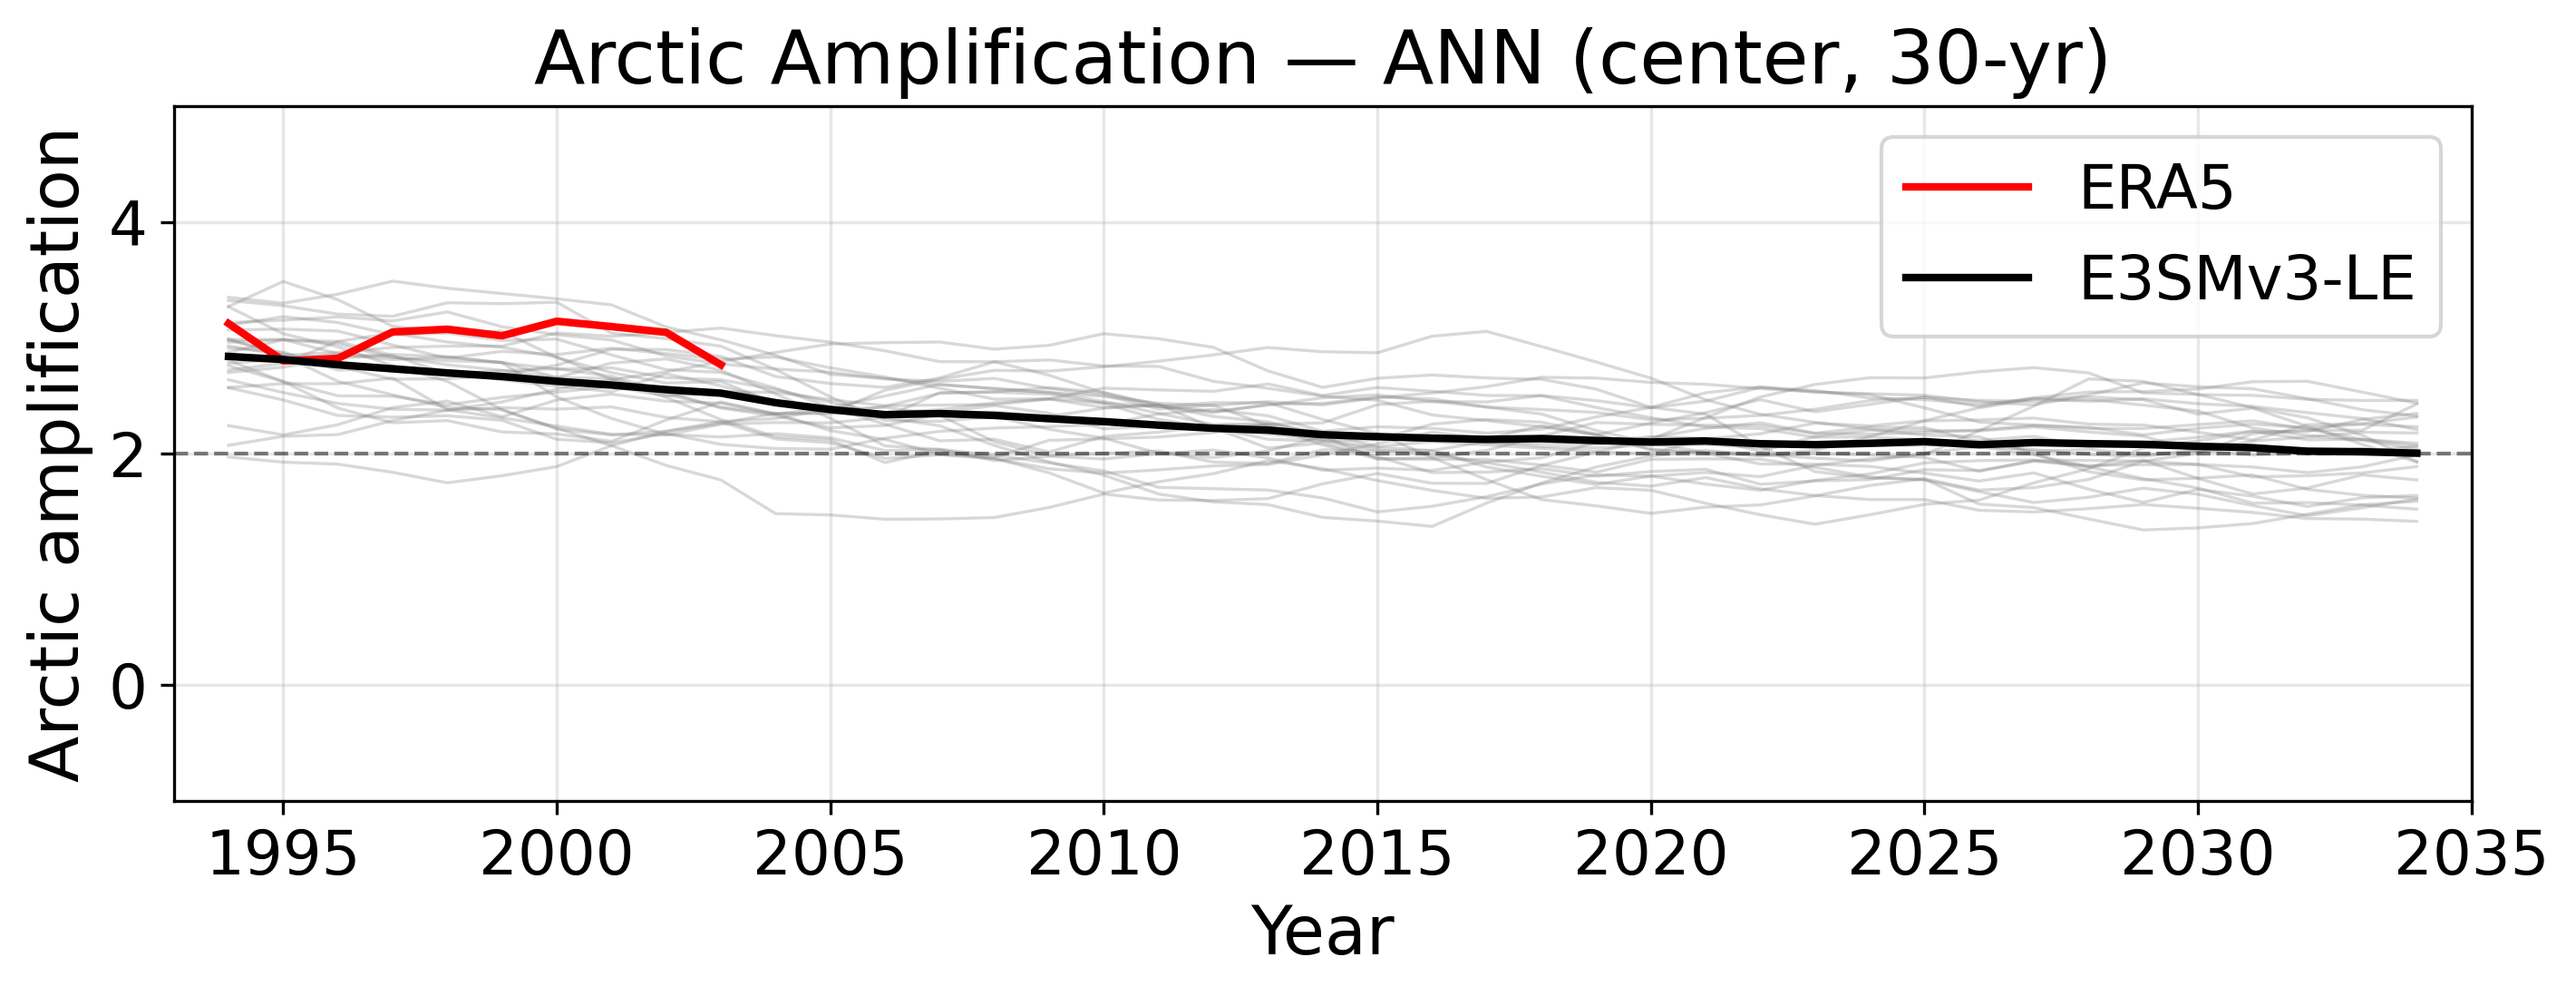

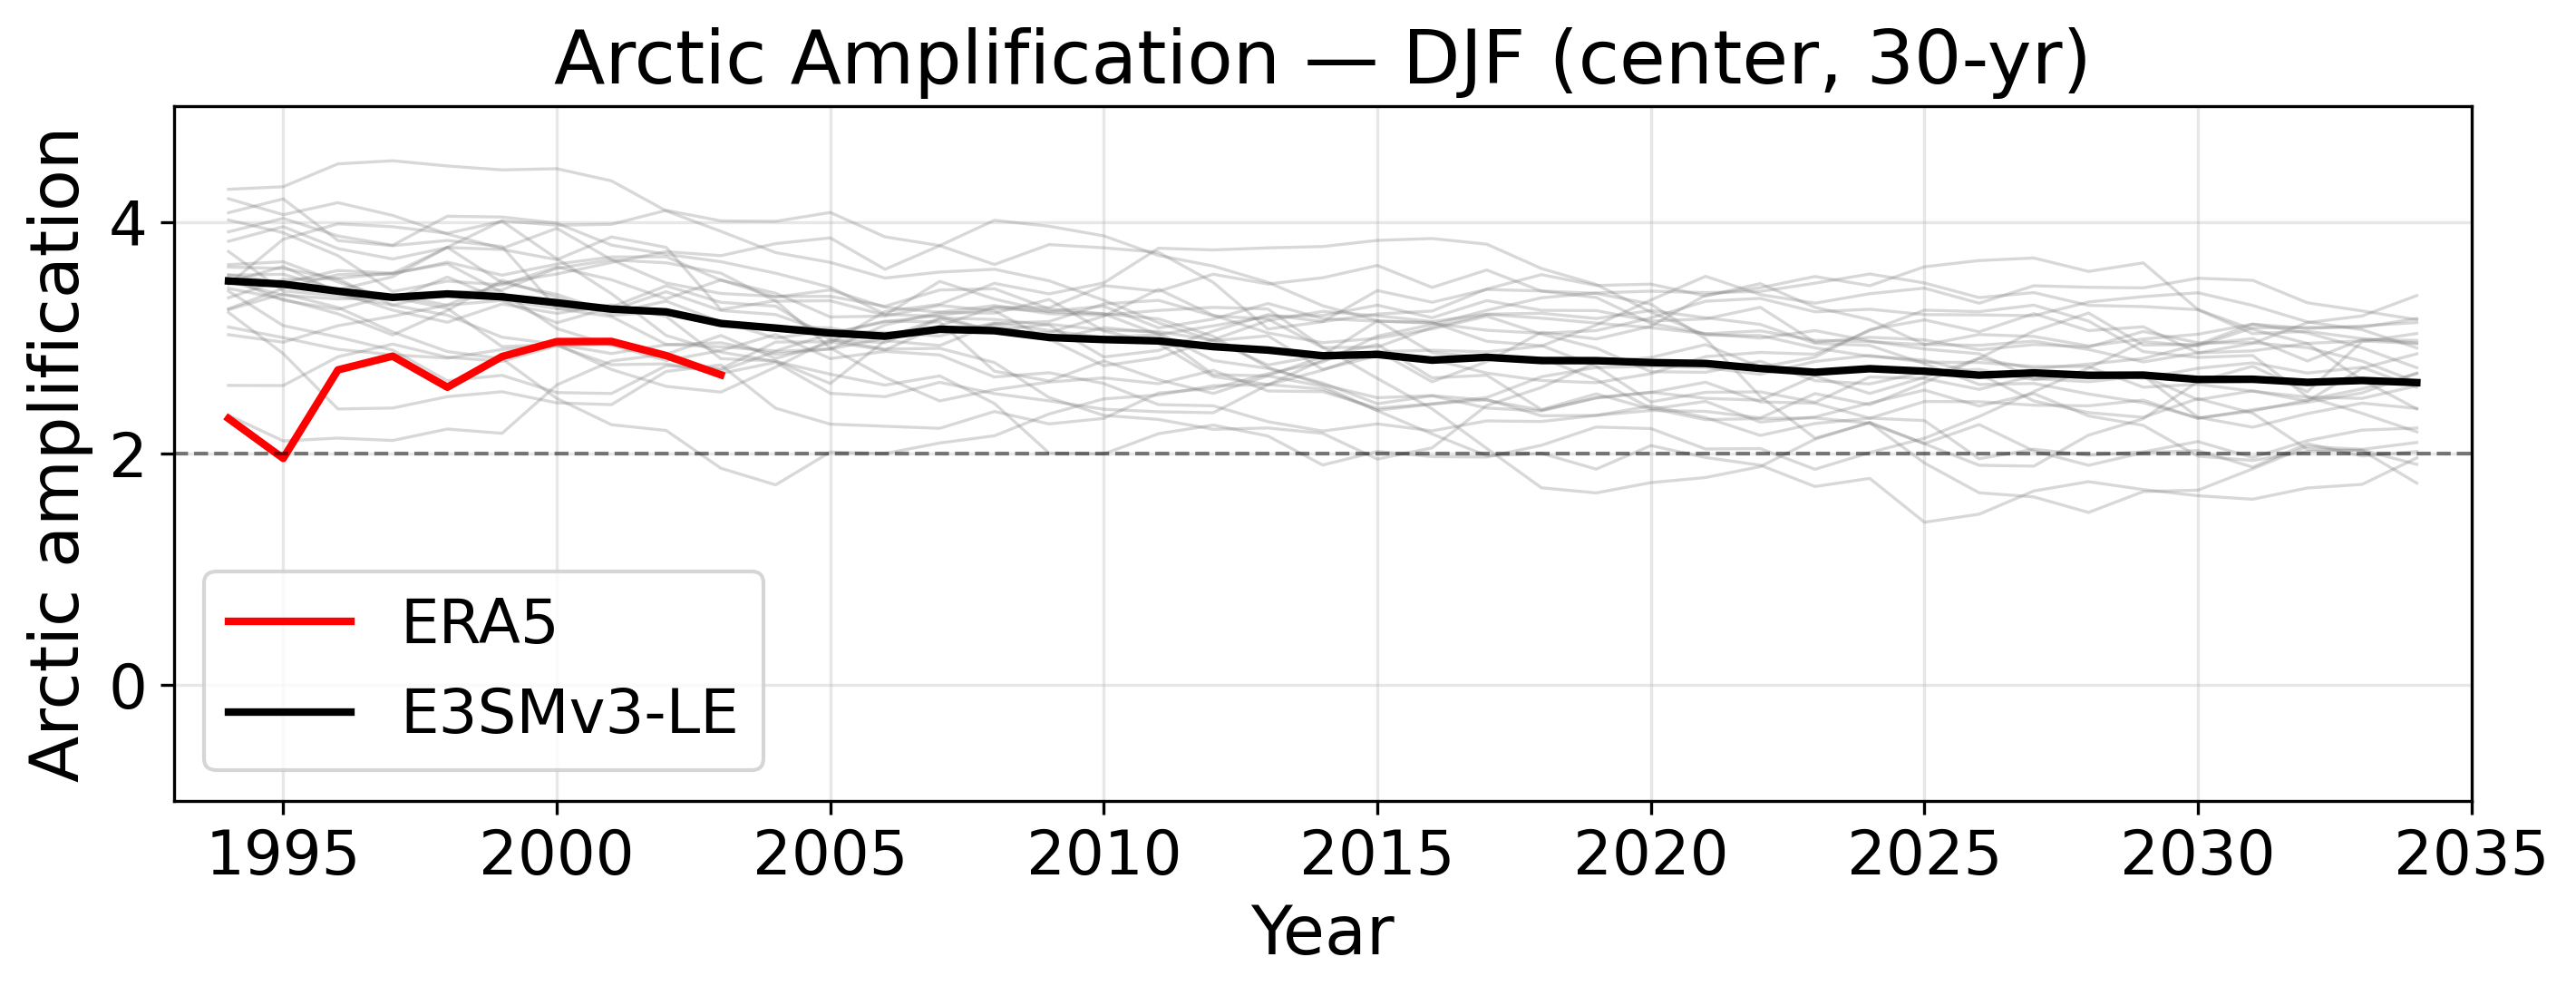

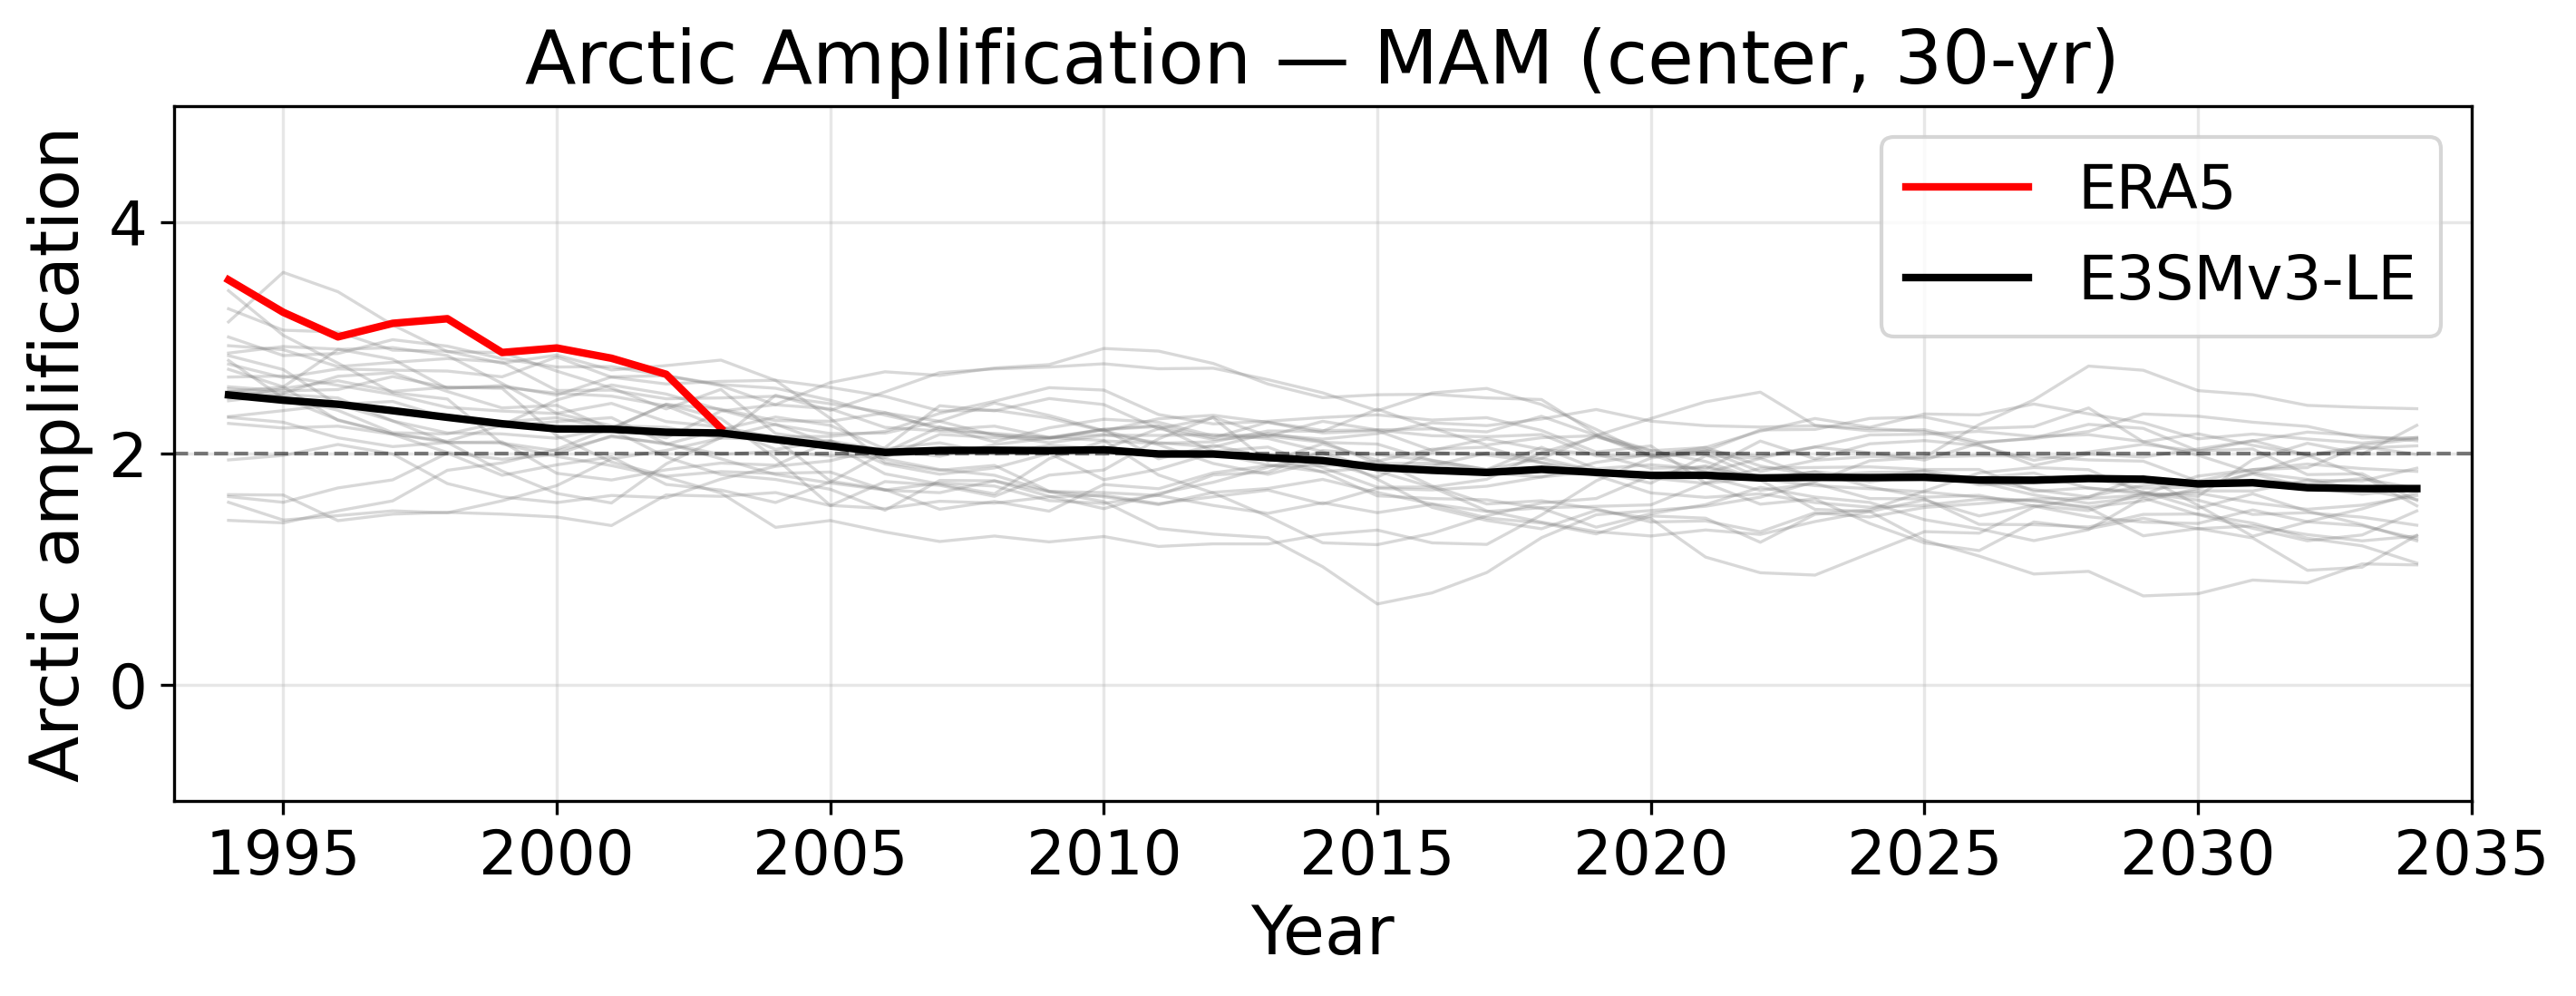

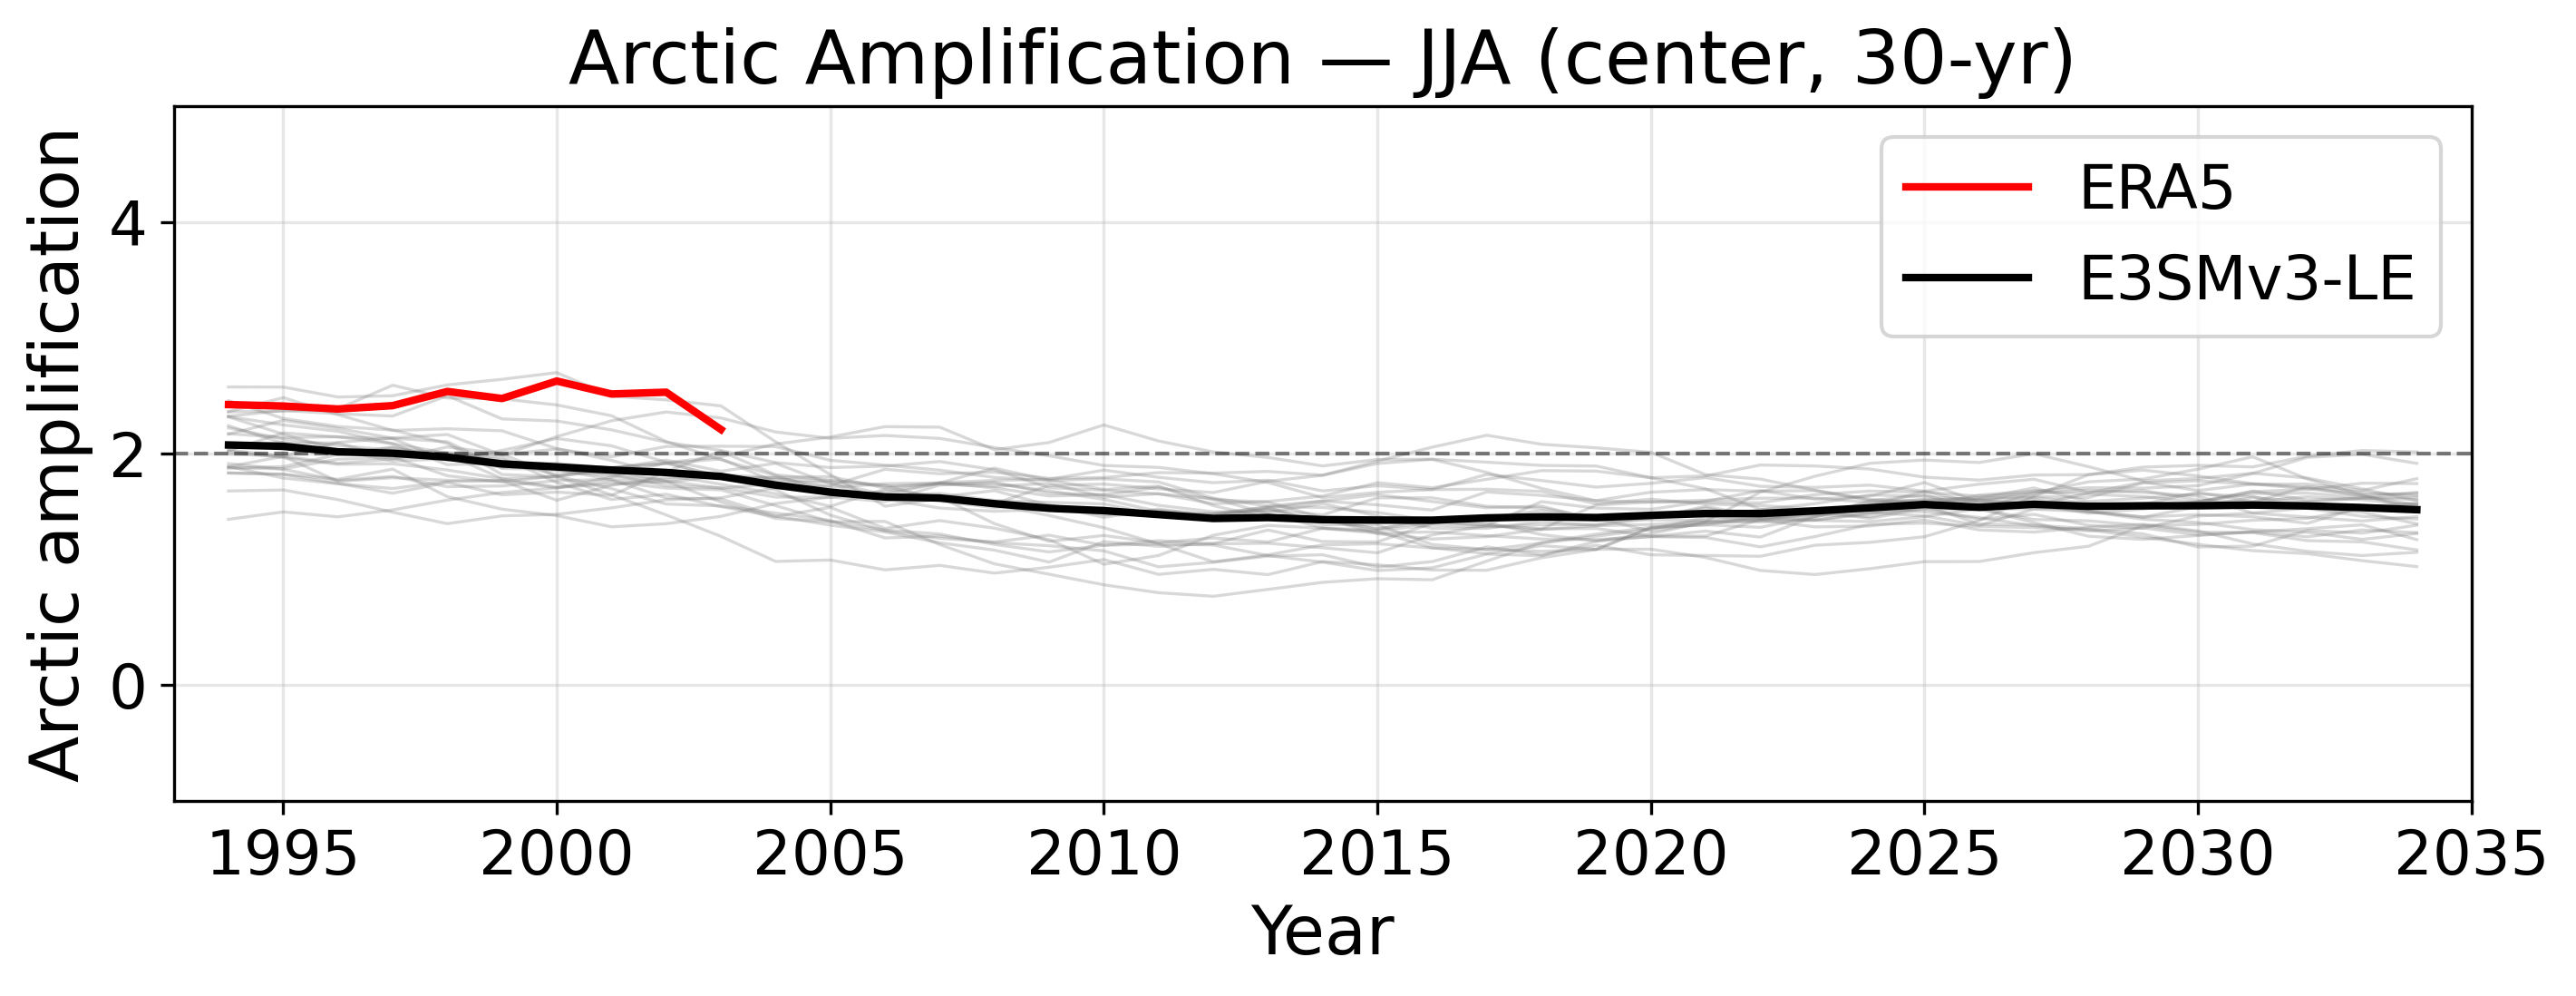

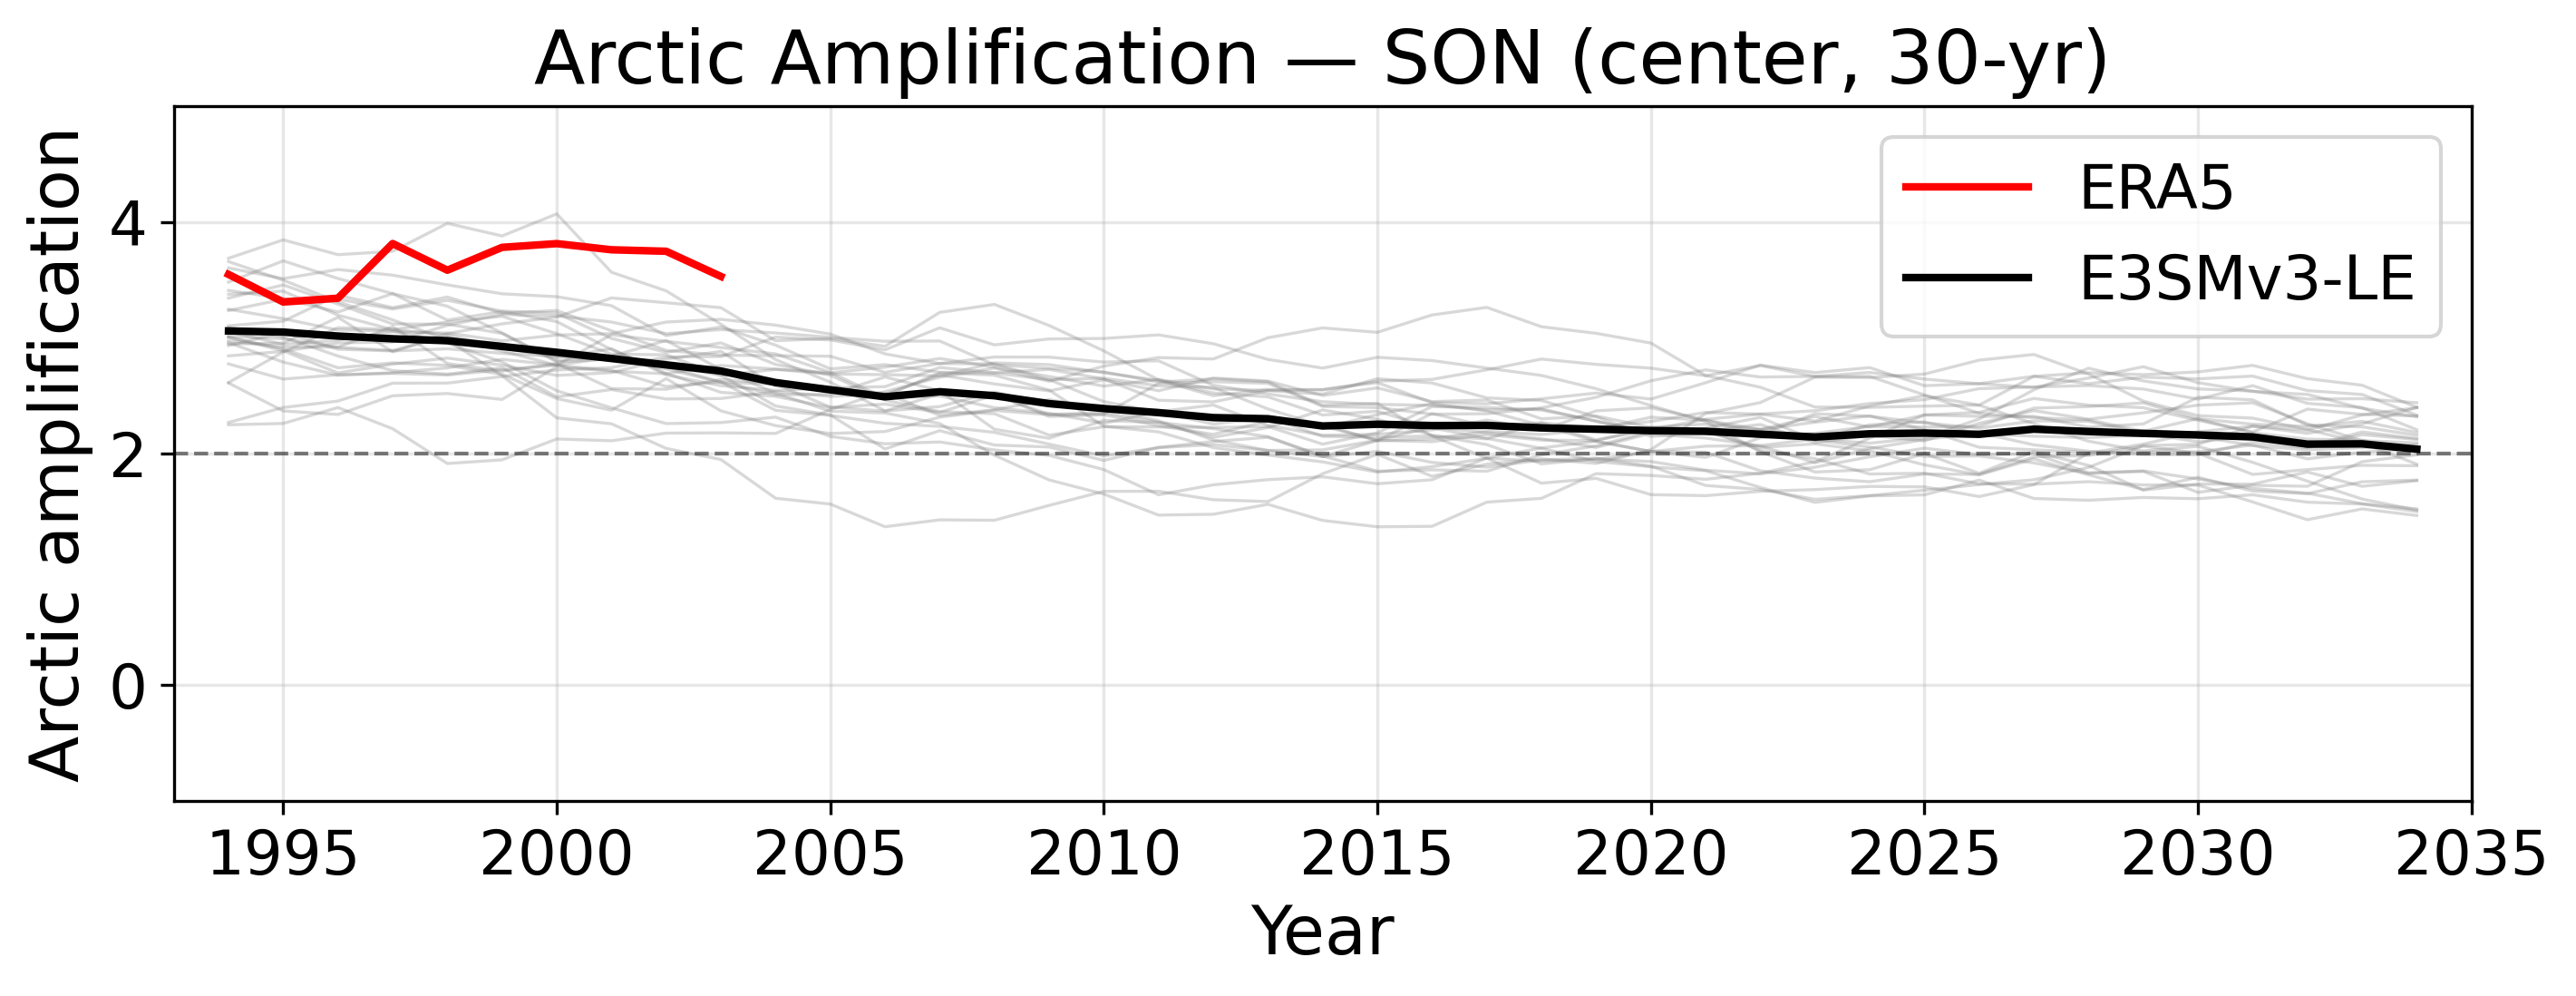

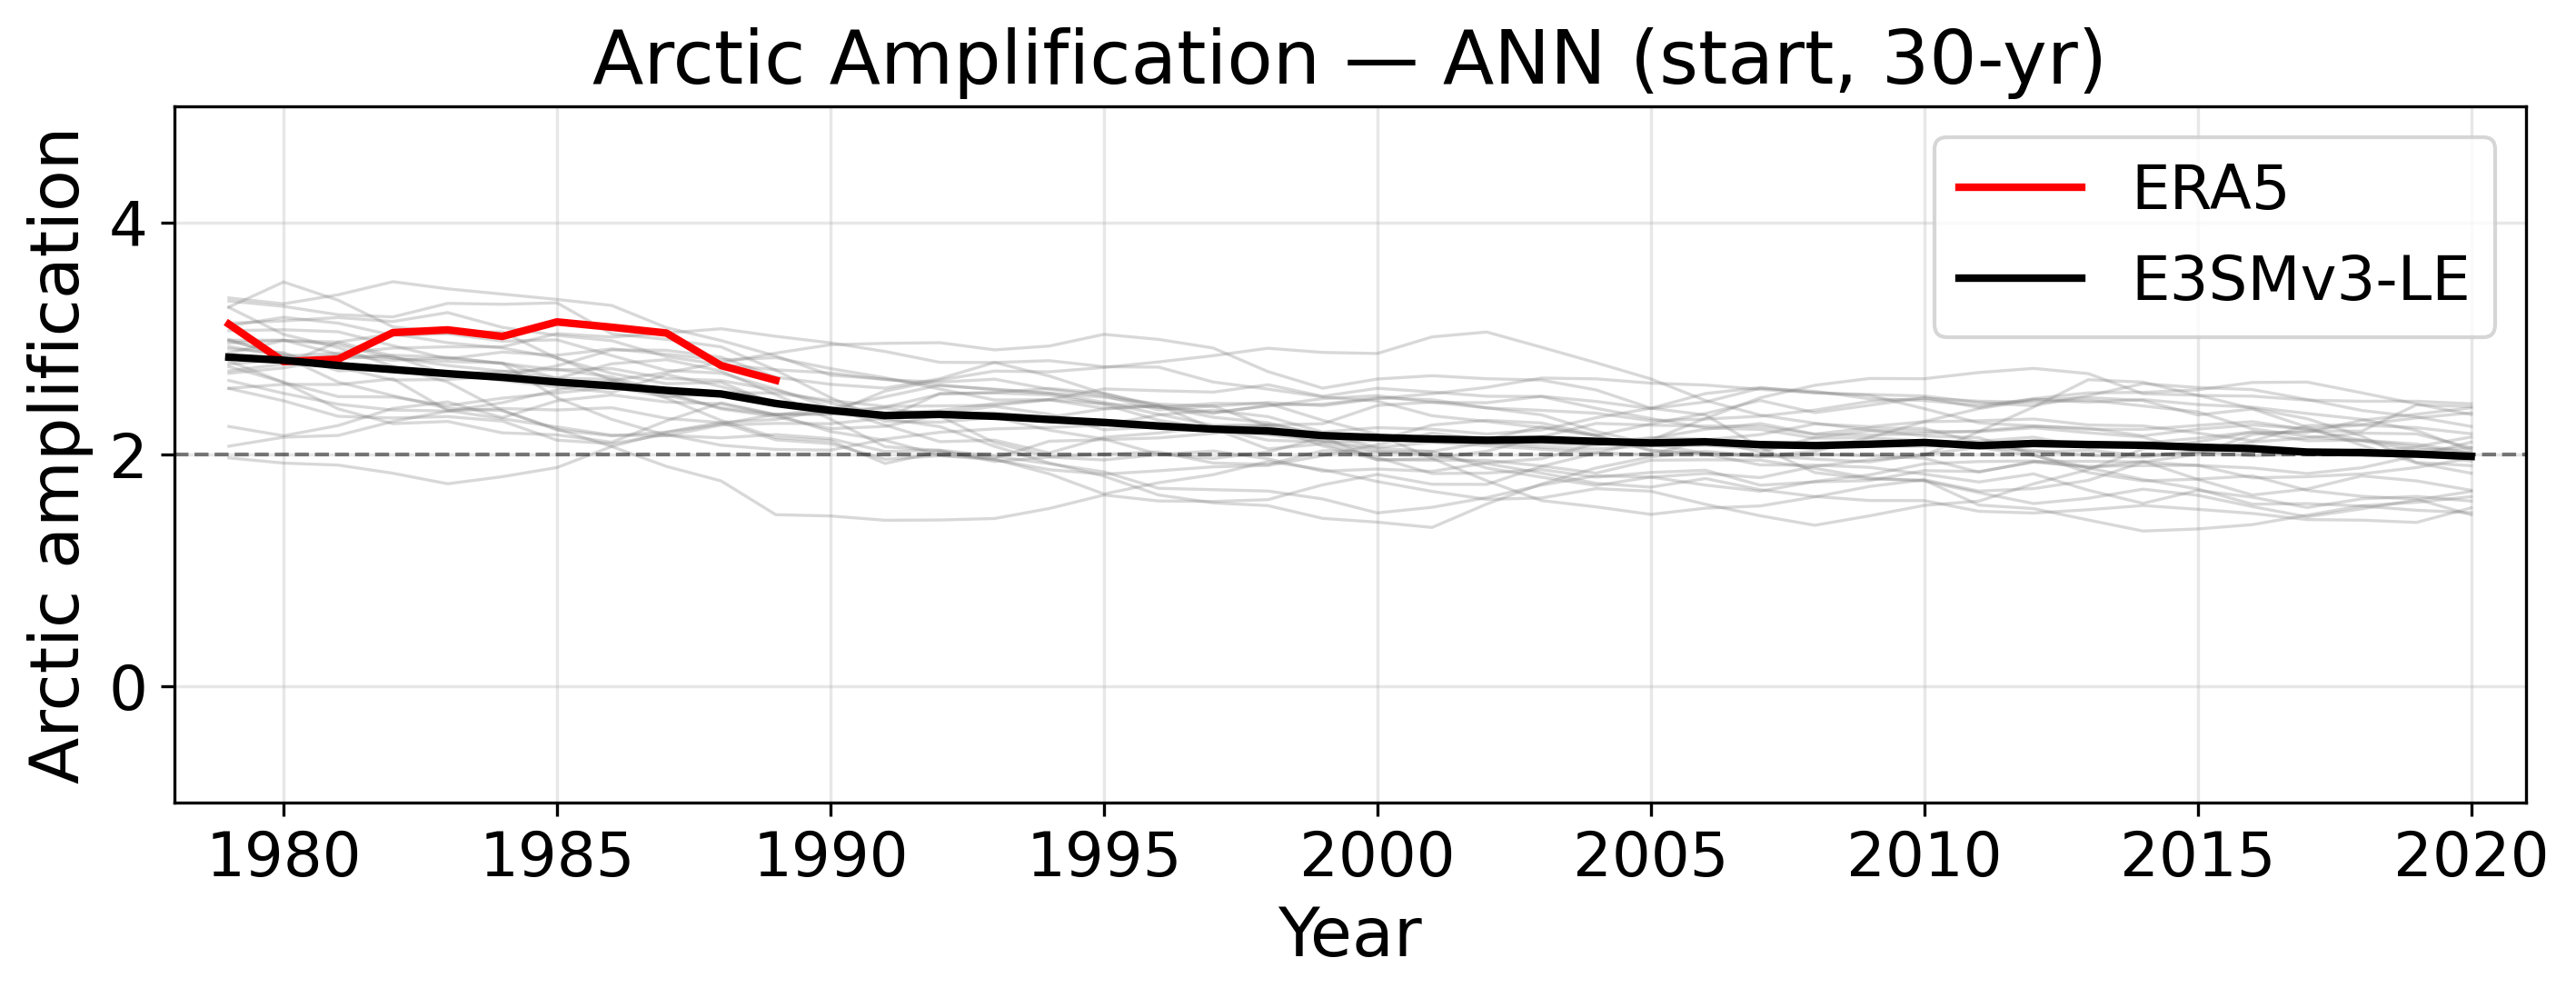

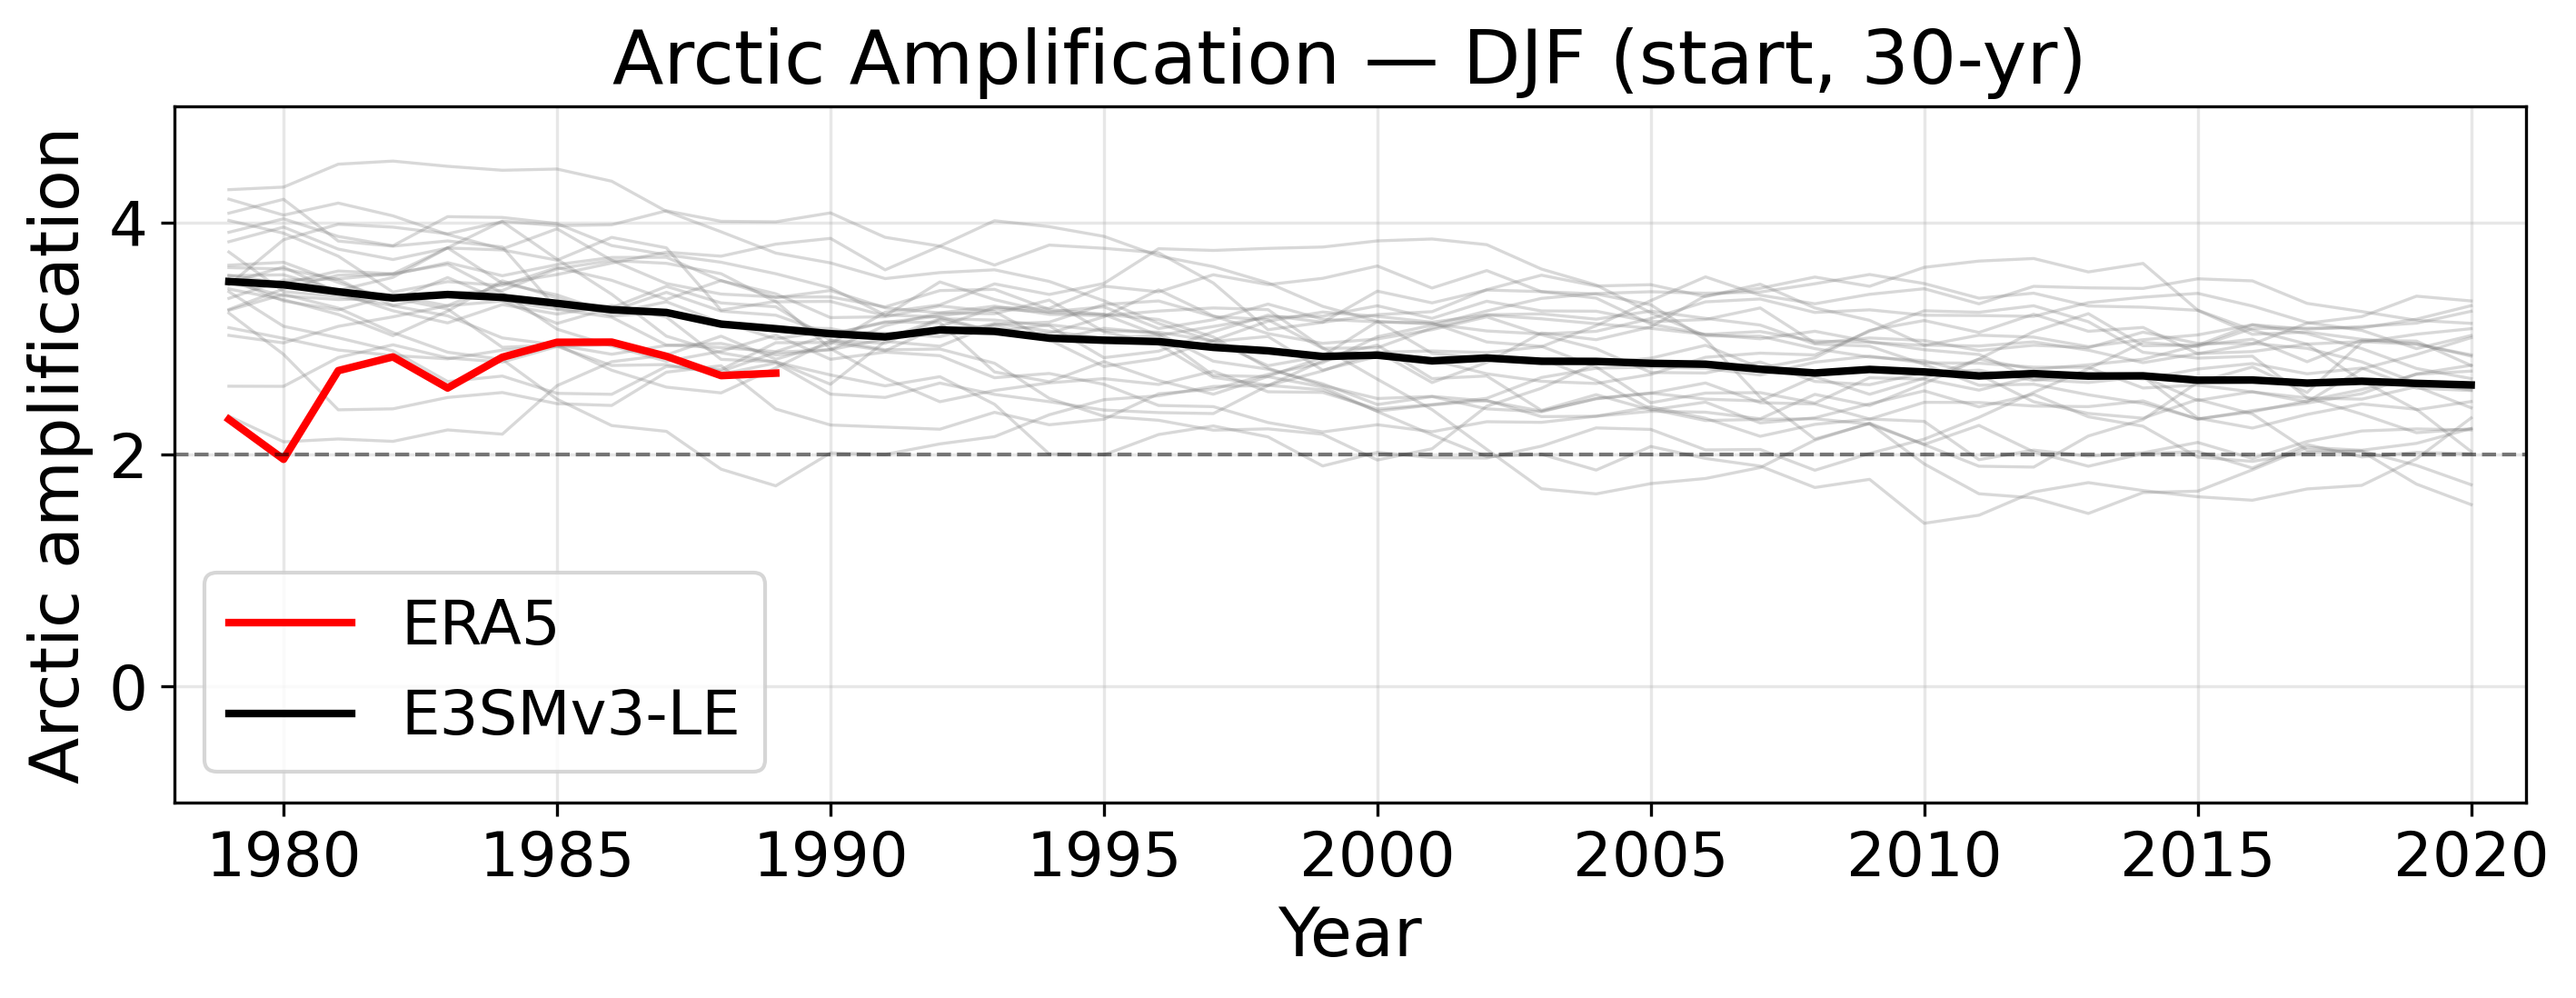

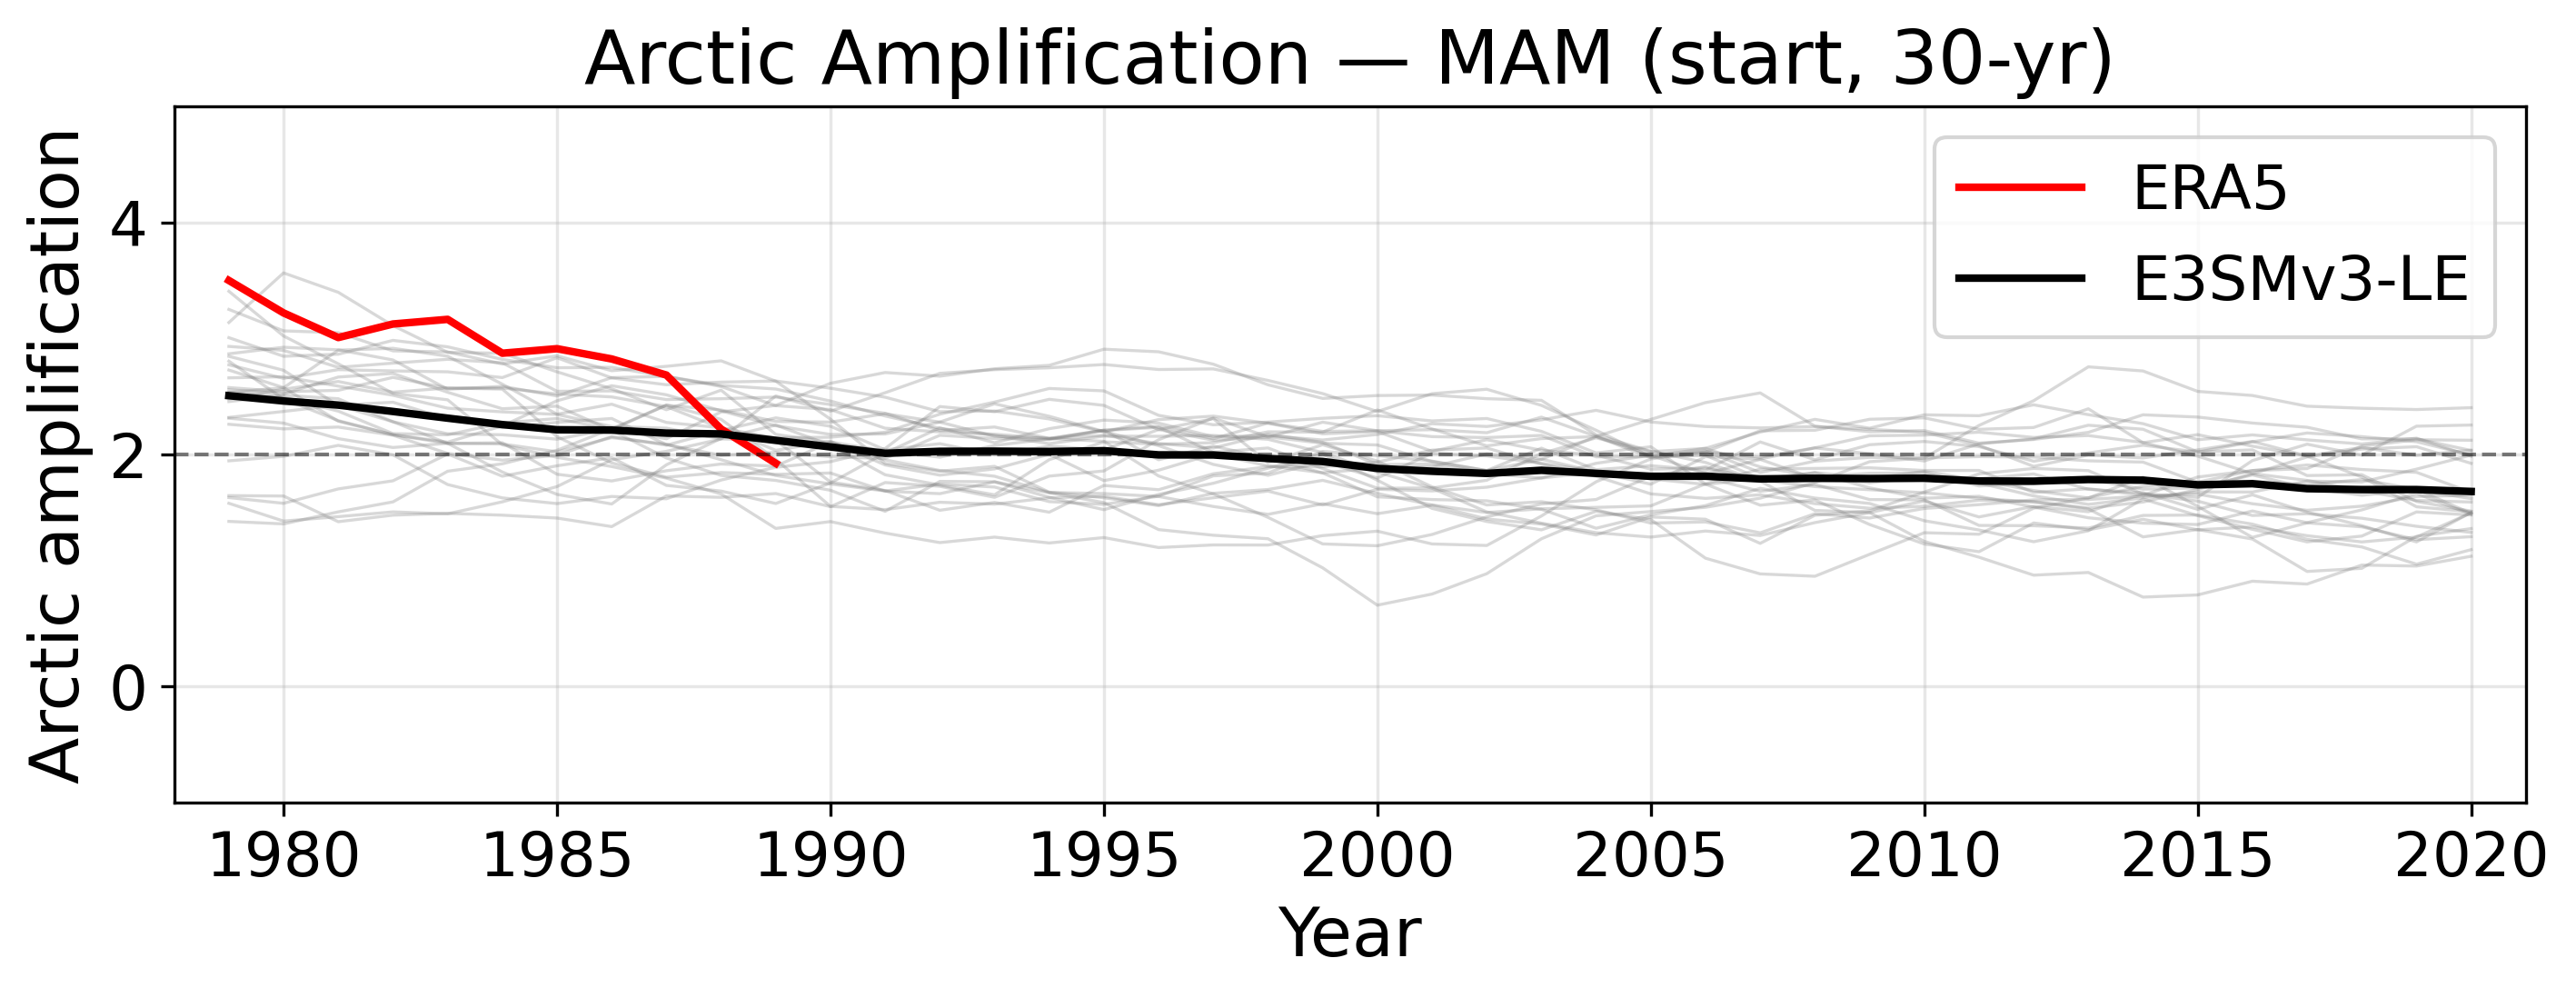

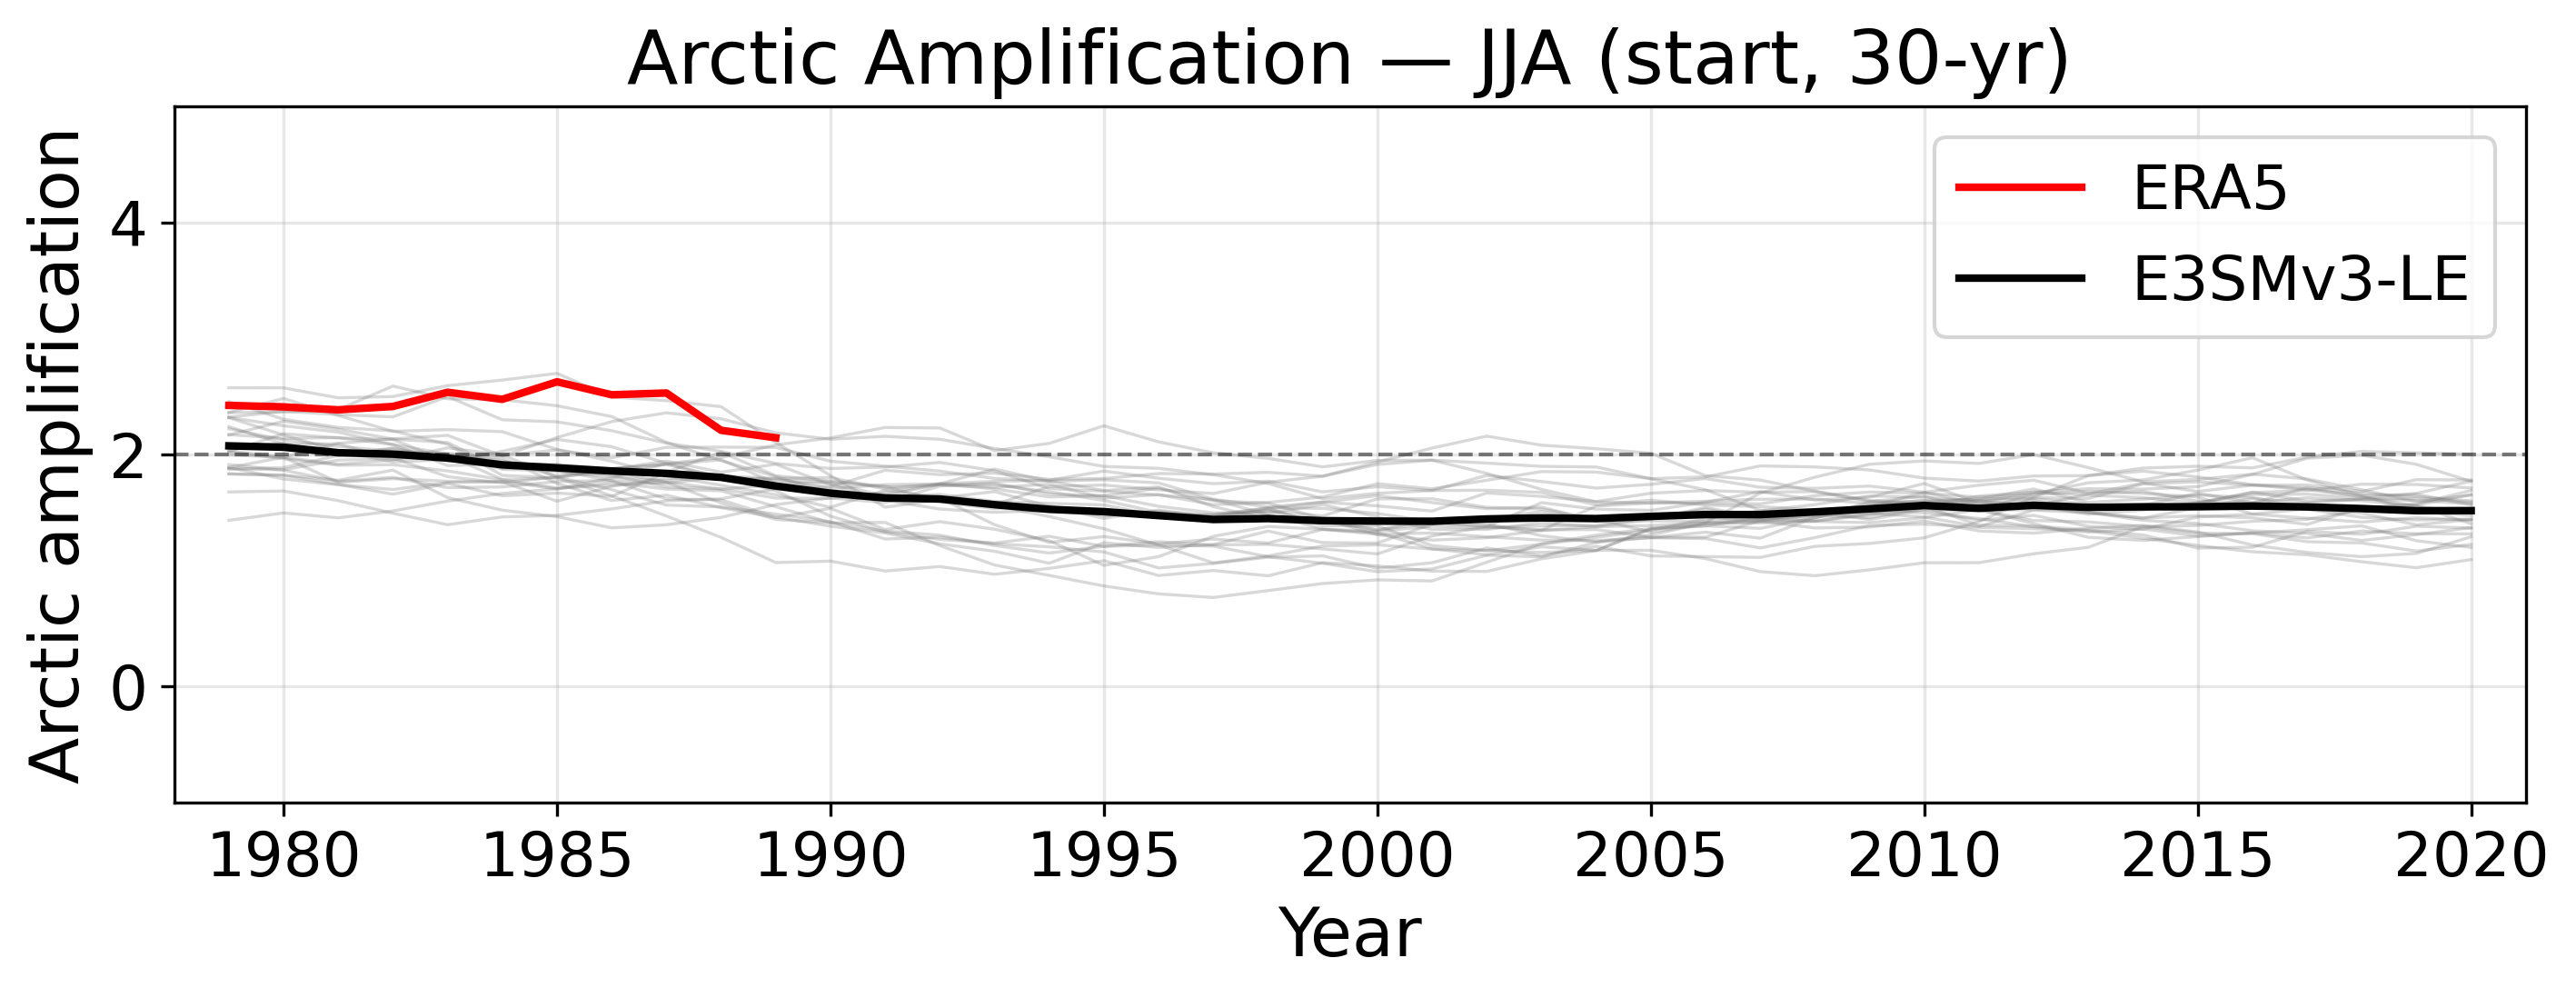

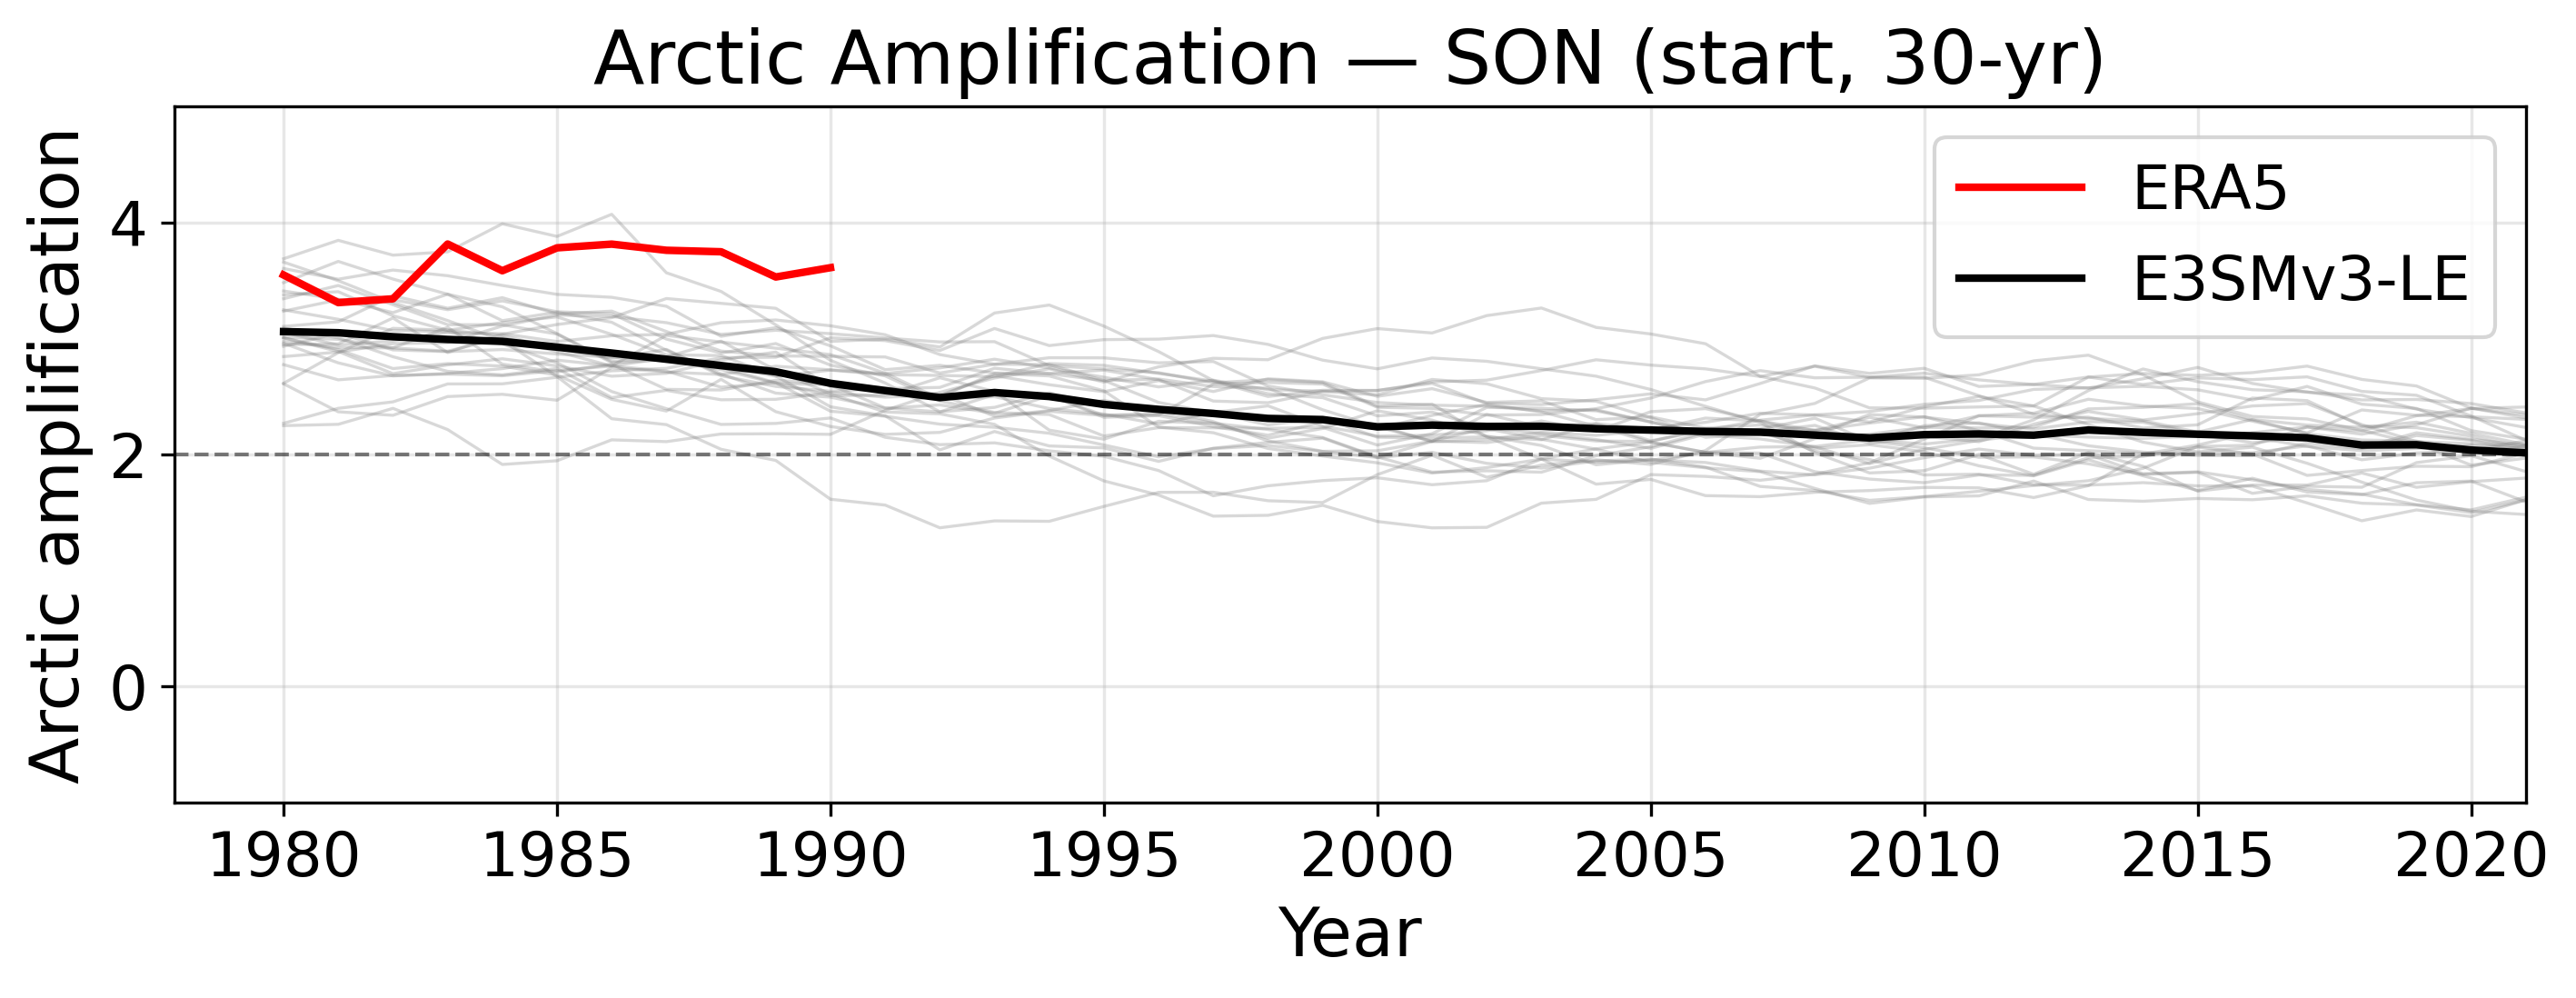

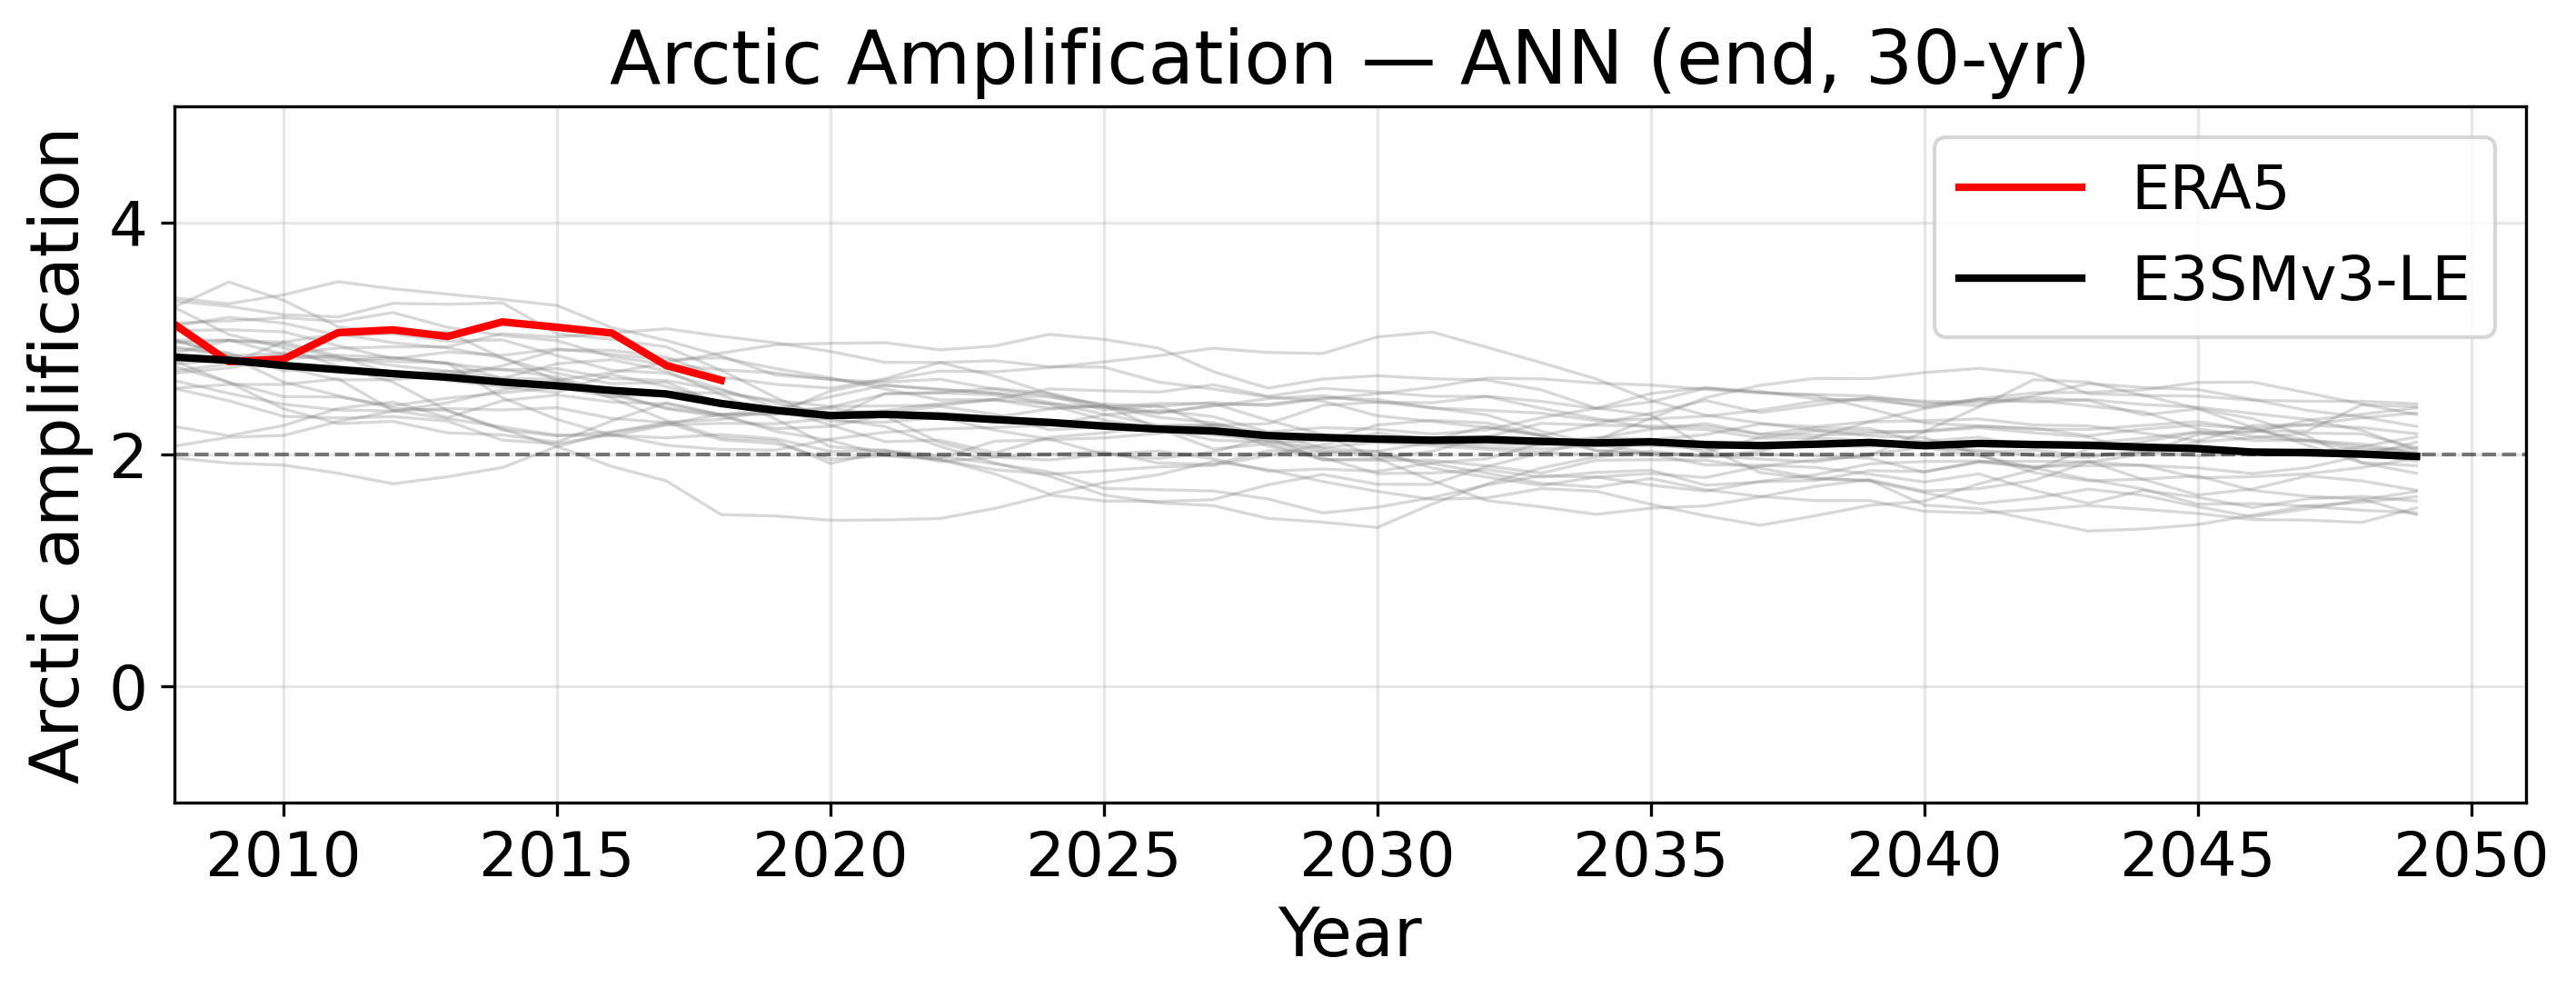

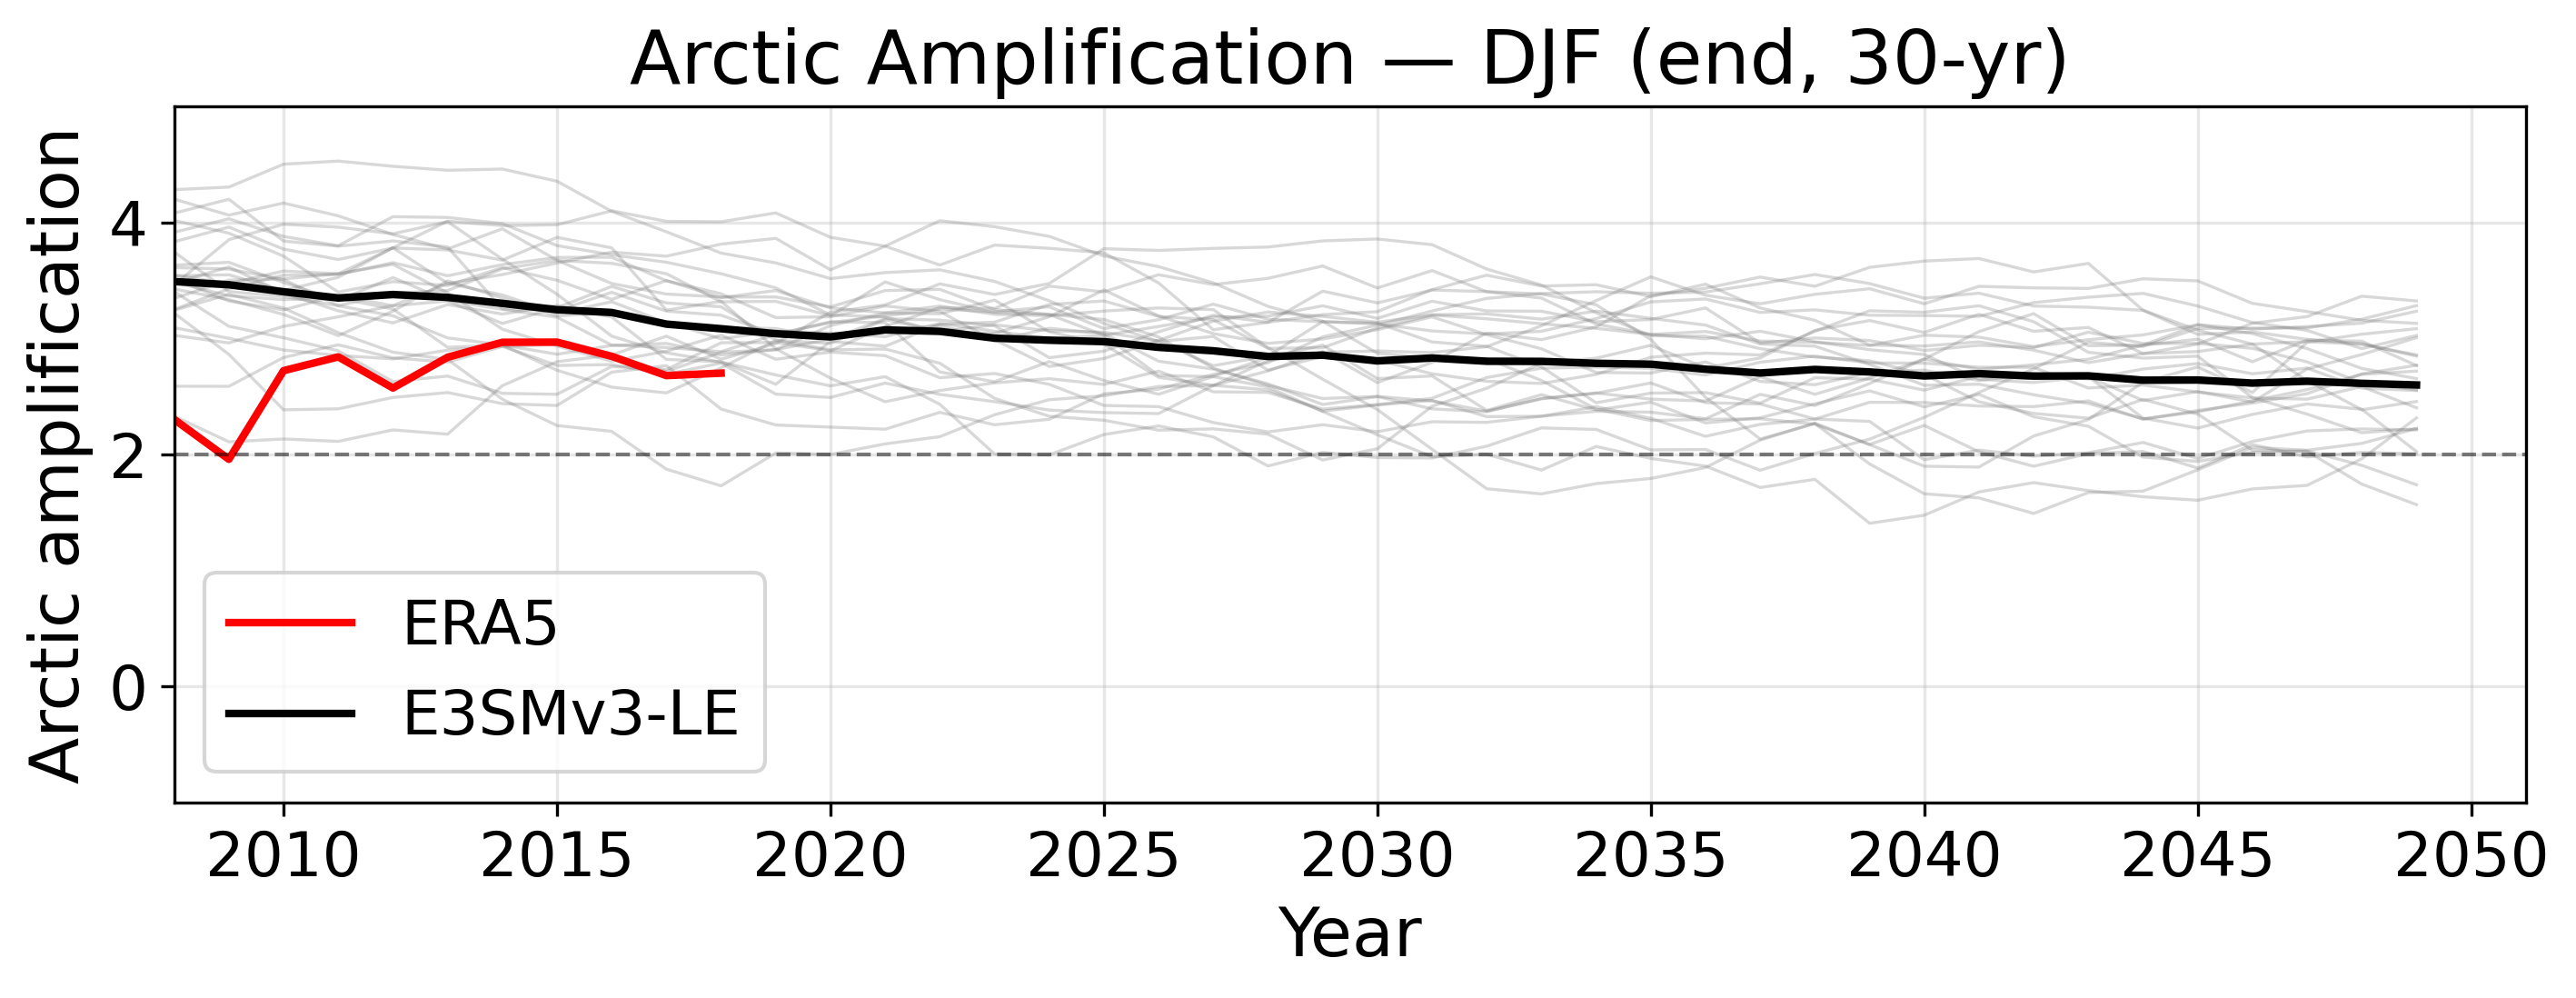

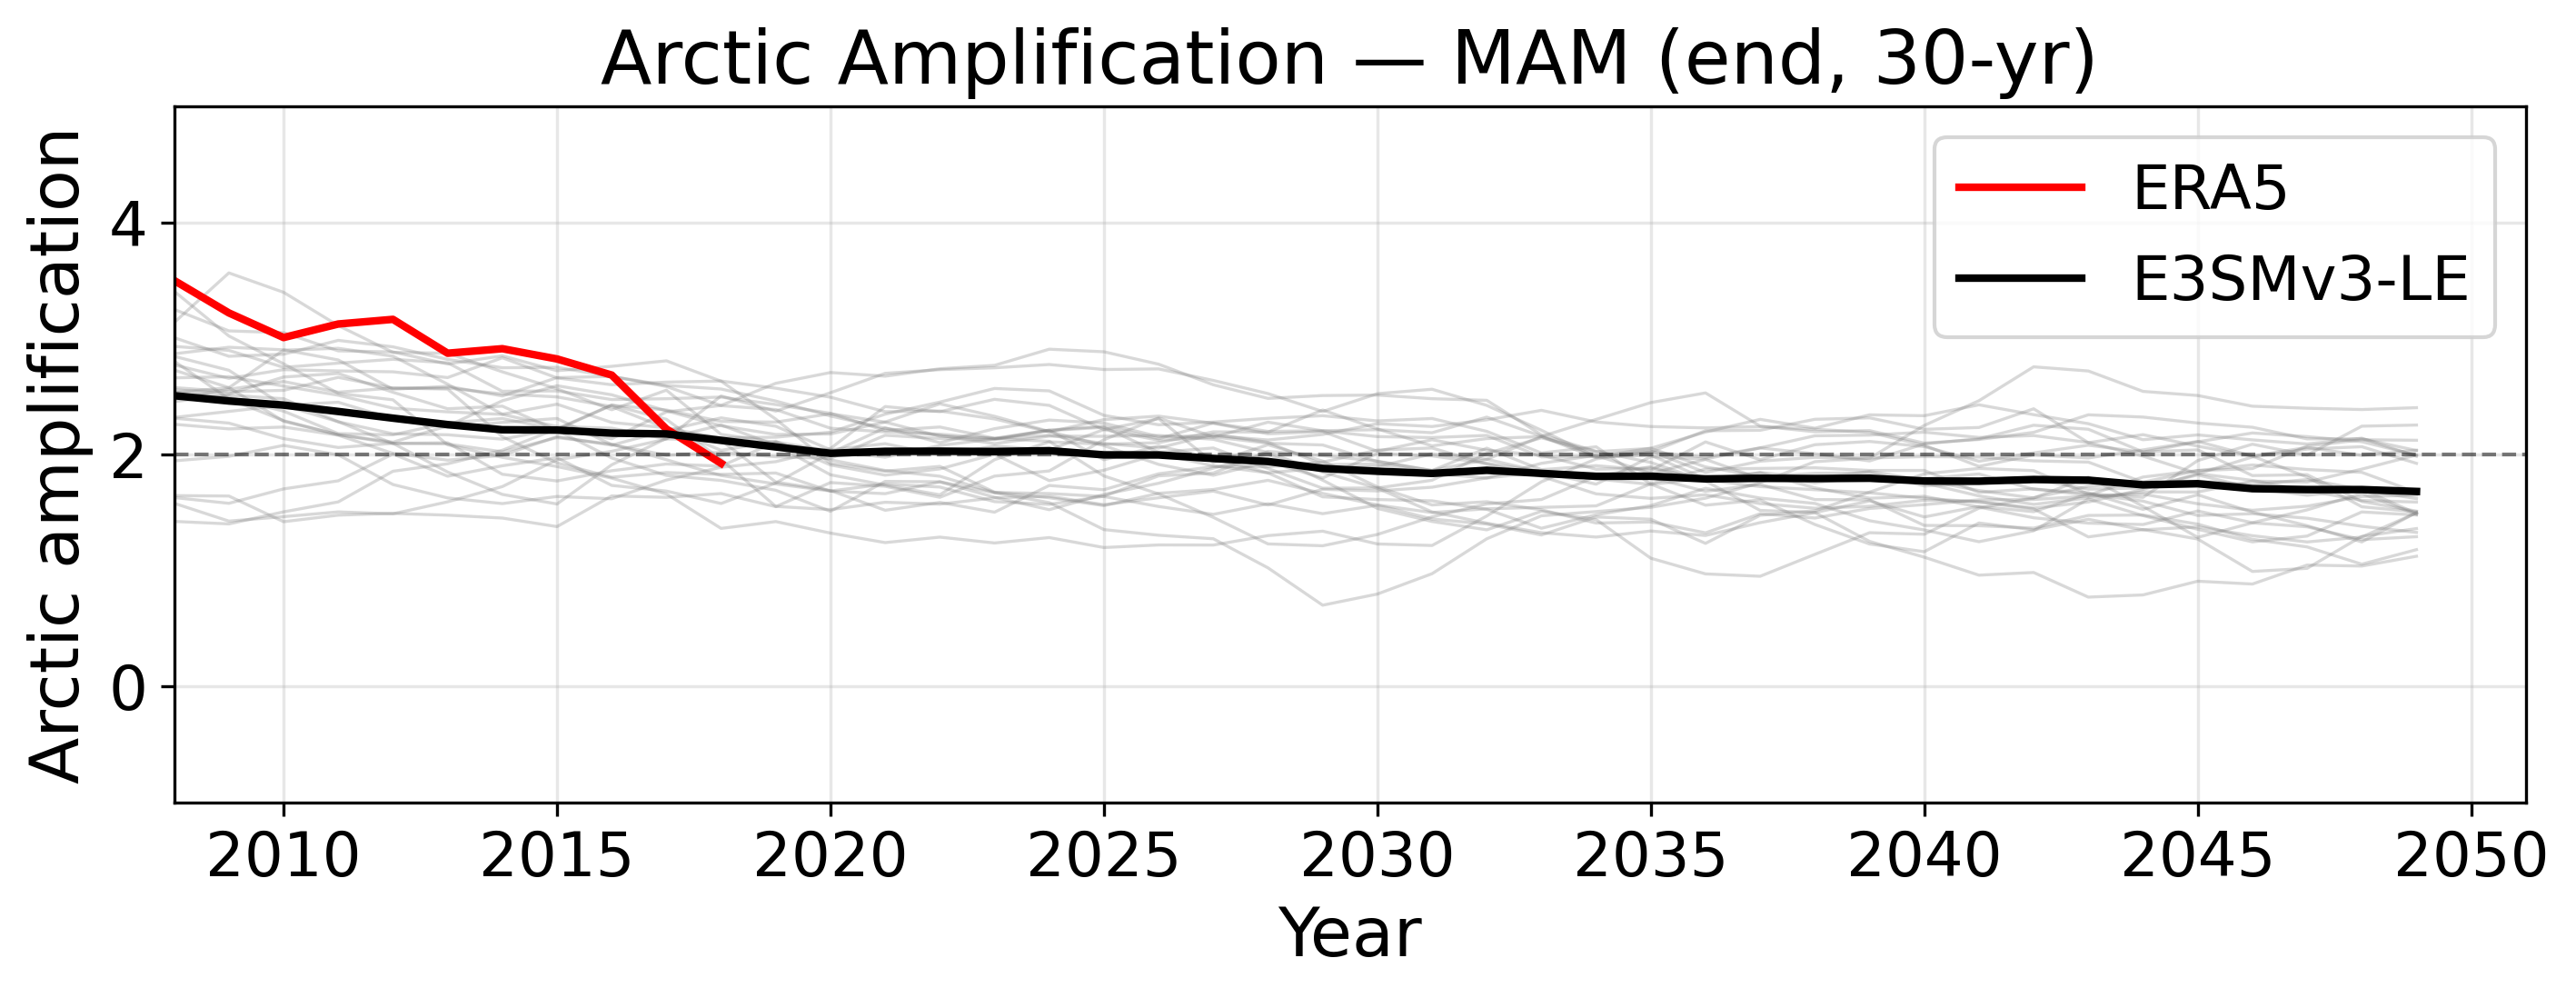

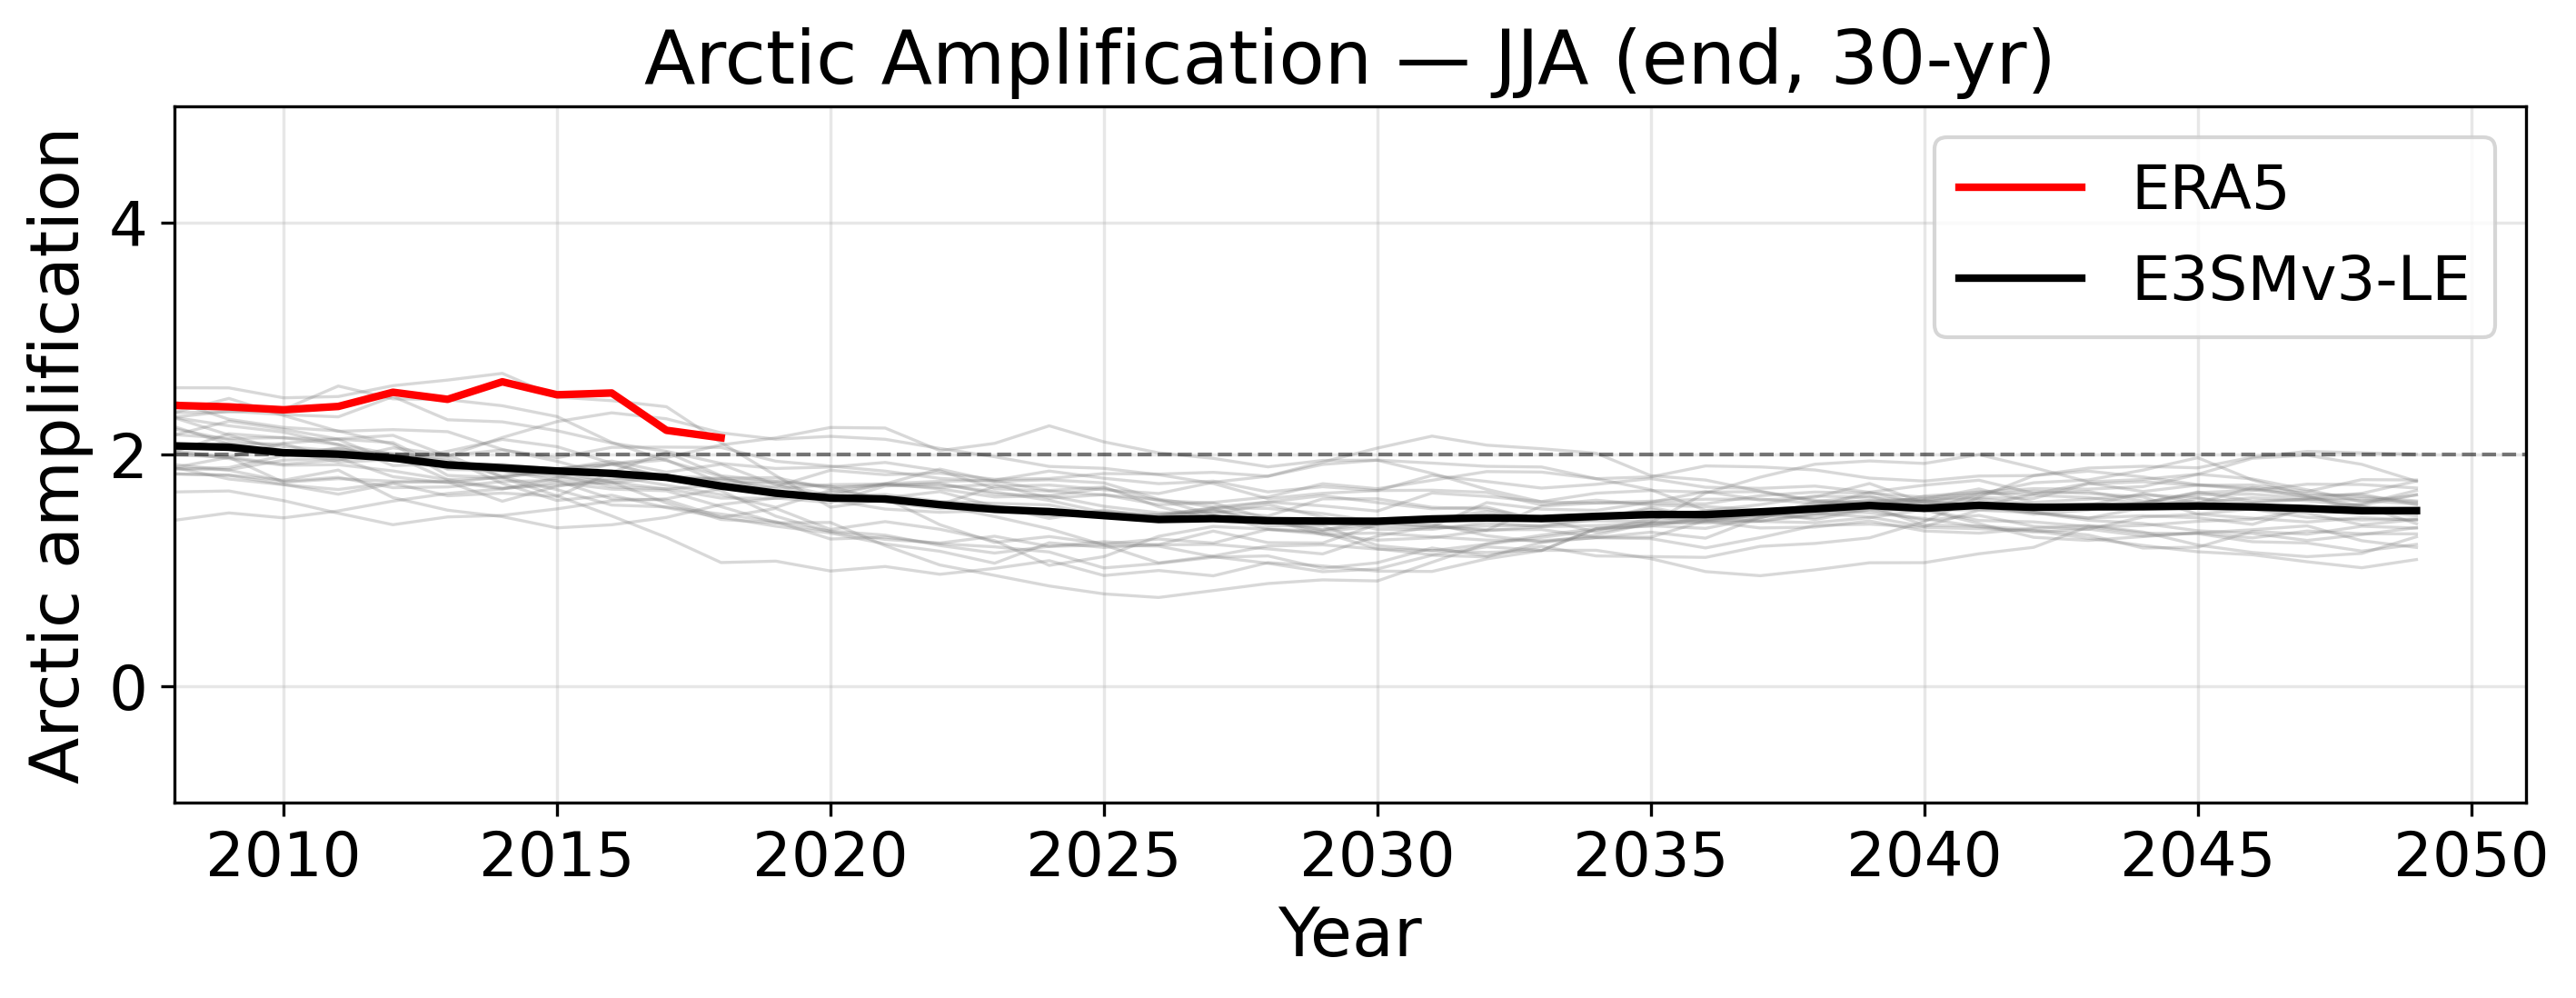

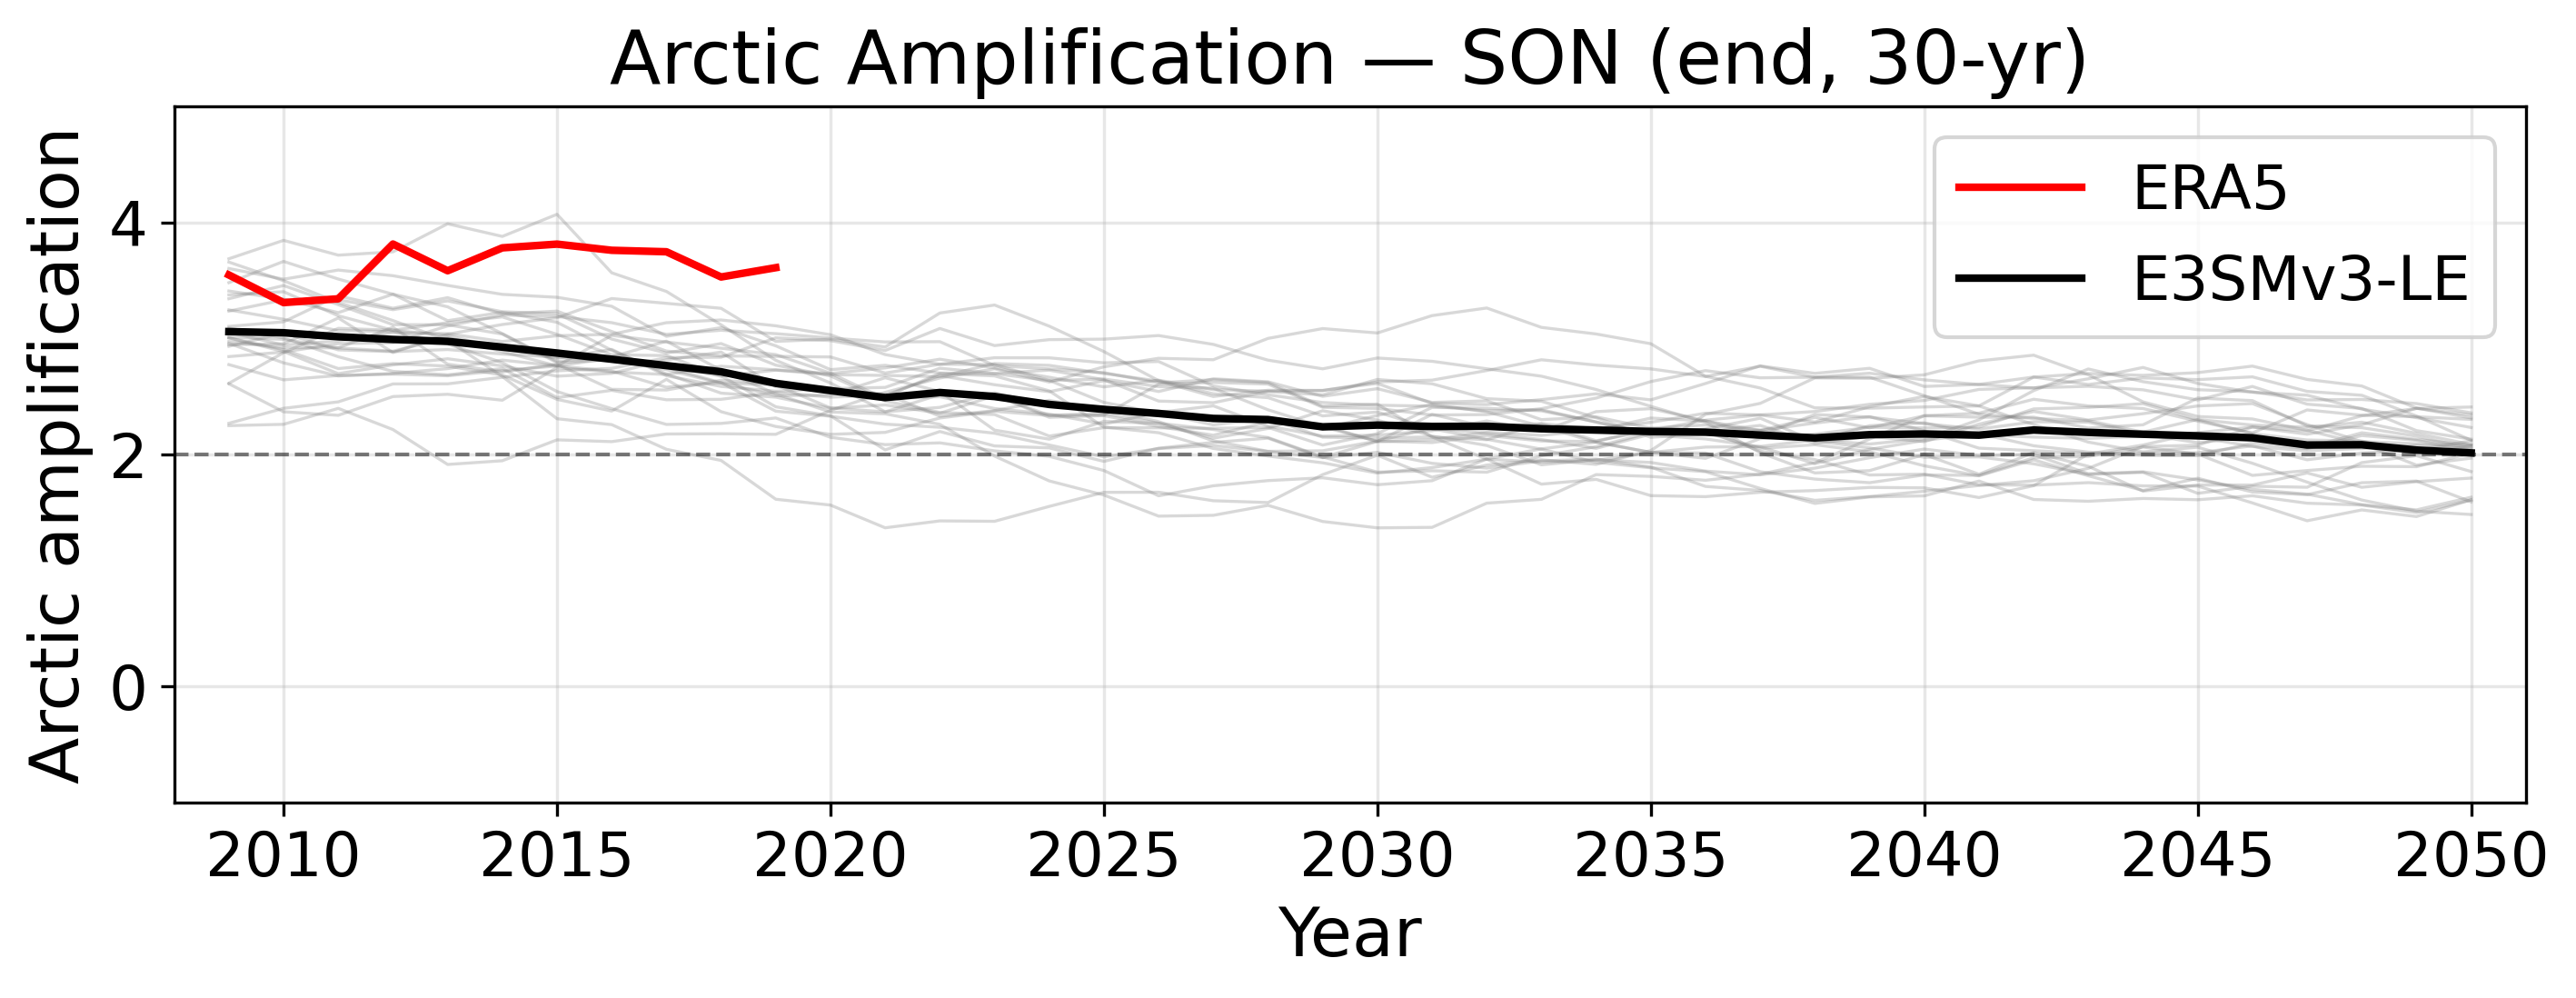

In [84]:
if __name__ == "__main__":
    TOP_DIR   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble"
    OUT_DIR   = f"{TOP_DIR}/figure_data"
    FIG_DIR   = str(FIG_DIR_ROOT)
    os.makedirs(FIG_DIR, exist_ok=True)

    EXPS    = ["ERA5", "E3SMv3-LE"]
    GROUPS  = ["ERA5", "v3.LR.historical"]
    VAR     = "TS"

    # IMPORTANT: must match what the processor used in filenames.
    # If the processor wrote 1979–2050, keep that; otherwise use 1979–2018.
    PTARGT  = (1979, 2050)

    SEASONS = ["ANN", "DJF", "MAM", "JJA", "SON"]
    ANCHORS = ["center", "start", "end"]   # ← run all three
    XRANGES = [(1993, 2035), (1978, 2021), (2008, 2051)]

    PREFIX_A = f"AA_{EXPS[0]}_ts_{GROUPS[0]}_{VAR}"      # ERA5
    PREFIX_B = f"AA_{EXPS[1]}_ts_{GROUPS[1]}_{VAR}"      # E3SMv3-LE
    
    stats_layout="side"   # ← new horizontal layout
    verbose=True
    show_stats=False
    show_ref_line=True
    ref_value=2.0
    trend_window=30          # keep in sync with processor
    xlim = (1975, 2050)
    ylim = (-1, 5)
    figsize = (10, 4)
    fontz = 18
    
    # Legacy pattern not needed; plotter resolves modern filenames automatically.
    plotter = ArcticAAPlotter(
        fig_dir=FIG_DIR,
        out_dir=OUT_DIR,
        ptargt=PTARGT,
        trend_window=trend_window,   # keep in sync with processor
        trend_anchor="",           # will be overridden in the loop
        stats_layout=stats_layout,   # ← new horizontal layout
        var=VAR,
        verbose=verbose,
        show_stats=show_stats,
        show_ref_line=show_ref_line,
        ref_value=ref_value,
        fontz=fontz
    )
    
    for i, anch in enumerate(ANCHORS):
        
        plotter.trend_anchor = anch  # makes it read *_30yr_{anch}.nc
        print(f"\n[ANCHOR] {anch}")
        xlim = XRANGES[i]

        # Prefixes must match your filenames: AA_{EXP}_{anchor}_ts_{GROUP}_{VAR}
        prefix_obs = f"AA_{EXPS[0]}_{anch}_ts_{GROUPS[0]}_{VAR}"      # ERA5
        prefix_mod = f"AA_{EXPS[1]}_{anch}_ts_{GROUPS[1]}_{VAR}"      # E3SMv3-LE

        for seas in SEASONS:
            title = f"Arctic Amplification — {seas} ({anch}, 30-yr)"
            out_name = f"AA_compare_{seas}_{anch}.pdf"
            plotter.plot_one(
                prefix_obs=prefix_obs,
                prefix_mod=prefix_mod,
                season=seas,
                title=title,
                xlim=xlim,
                ylim=ylim,
                labels=EXPS,
                figsize=figsize,
                out_name=out_name,
            )
